# Исследовательский анализ рынка общепита Москвы
## Проект спринта № 8

- Автор: Козлачкова Светлана
- Дата: 30.11.2025

### Цели и задачи проекта

Цель проекта заключается в проведении исследовательского анализа рынка общественного питания в Москве для выявления перспективных районов и категорий заведений.
В рамках выполнения проекта будут решены следующие задачи:
- Исследование количества объектов общественного питания по каждой категории
- Исследования распределения количества заведения по административным районам Москвы, а так же по Центральному административному округу
- Изучение соотношения сетевых и несетевых заведений в разрезе категорий заведений.
- Исследование количества посадочных мест в заведениях по категориям заведений
-Исследование рейтингов заведений и нахождение различий для разных типов общепита.
- Изучение корреляции рейтинга заведений с другими данными, которые могут повлиять на рейтинг. И проверка данных, у которых выявится самые сильные корреляции.
- Выявление ТОП-15 сетевых заведений по количеству заведений в Москве.
- Изучение вариации среднего чека заведения в зависимости от района Москвы, и нахождение взаимосвязи среднего чека с удаленностью от центра.

### Описание данных

Для анализа поступили данные с заведениями общественного питания Москвы, составленный на основе данных сервисов **Яндекс Карты** и **Яндекс Бизнес** 
на лето 2022 года. Данные состоят из двух датасетов: **`datasets/rest_info.csv`** и **`/datasets/rest_price.csv`**.



Файл **`/datasets/rest_info.csv`** содержит информацию о заведениях общественного питания:

- **`name`** — название заведения;
- **`address`** — адрес заведения;
- **`district`** — административный район, в котором находится заведение, например Центральный административный округ;
- **`category`** — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- **`hours`** — информация о днях и часах работы;
- **`rating`** — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- **`chain`** — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):   
- **`seats`** — количество посадочных мест.


Файл **`/datasets/rest_price.csv`** содержит информацию о среднем чеке в заведениях общественного питания:

- **`price`** — категория цен в заведении
- **`avg_bill`** — хранит среднюю стоимость заказа в виде диапазона
- **`middle_avg_bill`** — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
- **`middle_coffee_cup`** — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:

### Содержимое проекта

1. [Загрузка данных и знакомство с ними](#load)
2. [Подготовка единого датафрейма](#merge)
3. [Предобработка данных](#fix)
4. [Исследовательский анализ данных](#eda)
   
   4.1. [Количество объектов общественного питания по категориям](#count)
   
   4.2. [Распределение количества заведения по административным районам Москвы](#count_district)
   
   4.3. [Соотношение сетевых и несетевых заведений](#chain)
   
   4.4  [Количество посадочных мест в заведениях](#seats)
   
   4.5. [Рейтинг заведений](#rating)
   
   4.6. [Корреляция рейтинга заведений](#corr)
   
   4.7. [ТОП-15 сетевых заведений](#top)
   
   4.8  [Средний чек заведения в зависимости от района](#middle_bill)
   
5. [Итоговый вывод и рекомендации](#conclusion)
---

## 1. <a id='load'>Загрузка данных и знакомство с ними</a>

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix
import numpy as np
import sys

from fuzzywuzzy import fuzz
import missingno as msno

Для начала создадим датафрейм `rest_info`, куда выгрузим данные из датасета `/datasets/rest_info.csv`.

In [2]:
# выгружаем данные из датасета /datasets/rest_info.csv в датафрейм rest_info
try:   
    rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
except FileNotFoundError:
    rest_info = pd.read_csv('/datasets/rest_info.csv')

Познакомимся с данными датафрейма **`rest_info`** - выведем случайные 5 строк методом `sample()`, и информацию о датафрейме методом `info()`

In [3]:
# Выведем случайные 5 строк датафрейма rest_info
rest_info.sample(5, random_state = 102)

,id,name,category,address,district,hours,rating,chain,seats
2112,94d42d870a594de5866ac6b7fdc292b6,Чинар-А,ресторан,"Москва, улица Сокольнический Вал, 22",Восточный административный округ,"ежедневно, 11:00–23:00",4.3,0,48.0
75,c55fca54a52b477d828f38dc7444bc47,Хинкали-Gали!,кафе,"Москва, Дмитровское шоссе, 100",Северный административный округ,"ежедневно, 12:00–23:00",4.9,1,NaN
8358,f2cd851970414da98de95fc771f0308d,Зар,кафе,"Москва, Волгоградский проспект, 42к7",Юго-Восточный административный округ,пн-пт 07:00–19:00; сб 10:00–17:00,3.7,0,NaN
368,2f8694ca435745738e1d4014c3b3d33d,МСК Lounge,"бар,паб","Москва, Кронштадтский бульвар, 6, корп. 2",Северный административный округ,"пн-пт 11:00–05:00; сб,вс 12:00–05:00",4.4,1,84.0
2133,4c2d33b0597c40b085e26e041bd2d896,Тапчан,ресторан,"Москва, Русаковская улица, 27",Восточный административный округ,"пн-чт 11:00–01:00; пт,сб 11:00–03:00; вс 11:00...",4.3,1,200.0


In [4]:
#Выведем информацию о датафрейме rest_info
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датафрейм **`rest_info`** состоит из 8406 строк и 9 столбцов, в которых представлена информация о заведениях общественного питания в Москве.
Названия столбцов корректно отображают содержимое данных и приведены к единому стилю.
В столбцах `hours` и `seats` имеются пропуски, однако  следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
6 столбцов (`id`, `name`, `category`, `address`, ` district`, `hours`) содержат строковые данные и имеют тип `oblect`. Cтолбцы `rating` и `seats` представлены типом `float64` и столбец `chain` имеет тип `int64`. Для большинства столбцов тип данных выбран верно. Столбец `seats` отображает количество посадочных мест, поэтому его необходимо преобразовать в тип `int`, а столбец `chain` принимает числовое значение 0 или 1, и размерность этих данных нужно будет оптимизировать.

Далее познакомимся с данными из датасета `/datasets/rest_price.csv`, который содержит информацию о среднем чеке в заведениях общественного питания.
Выгрузим данные в датафрейм `rest_price`, выведем из него 5 случайных строк и посмотрим информацию о датафрейме. 

In [5]:
# выгружаем данные из датасета datasets/rest_price.csv в датафрейм rest_price
try:   
    rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')
except FileNotFoundError:
    rest_price = pd.read_csv('/datasets/rest_price.csv')

In [6]:
# Выведем случайные 5 строк датафрейма rest_price
rest_price.sample(5, random_state = 8)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
2165,74fc6207eba54304af865ff6c019d920,средние,Цена чашки капучино:270–280 ₽,NaN,275.0
3678,beb90dc071574976a2f614c964446bf1,средние,Средний счёт:250–300 ₽,275.0,NaN
1391,b7728684459d43a18c8e61d206c9836c,средние,Цена чашки капучино:145–225 ₽,NaN,185.0
1550,9f2ed707c5d14b66ae21c4ad9118d9b2,средние,Средний счёт:600–800 ₽,700.0,NaN
1670,c9e6e817831b4444ac7cbf74a513b61e,средние,Средний счёт:280–450 ₽,365.0,NaN


In [7]:
#Выведем информацию о датафрейме rest_price
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датафрейм `rest_price` содержит в себе 4058 строк и 5 столбцов, в которых находится информация о среднем чеке в заведениях общественного питания.
Названия столбцов корректно отображают содержимое данных и приведены к единому стилю. Столбцы `id`, `price`, `avg_bill` представлены типом 'object',
а столбцы `middle_avg_bill`, `middle_coffee_cup` типом 'float64'.  На первый вгляд столбцы `middle_avg_bill` и  `middle_coffee_cup` можно привести в типу `int64`, в случае если у них отсутствует дробная часть.
В 4 из 5 столбцах содержатся пропуски данных. 


---

### Промежуточный вывод

Нам было предоставлено два датасета **`datasets/rest_info.csv`** и **`/datasets/rest_price.csv`**, содержащих информацию о заведениях 
общественного питания г. Москвы и среднем чеке. Они были выгружены в датафреймы `rest_info` и `rest_price`.

Датафрейм **`rest_info`** состоит из 8406 строк и 9 столбцов. В столбцах `hours` и `seats` обнаружены пропуски данных. Столбцы `seats` и `chain` необходимо преобразовать к другим типам данных.

Датафрейм **`rest_price`** содержит в себе 4058 строк и 5 столбцов. В четырех столбцах `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup` были обнаружены пропуски. Для всех столбцов типы данных подобраны корректно, онако для столбцов `middle_avg_bill` и  `middle_coffee_cup` возможно преобразование, в случаях если данные не содержат дробной части.
Названия столбцов обоих датафреймов отображены корректно и соответствуют единому стилю написания `snake_case`.

### <a id='merge'>2. Подготовка единого датафрейма</a>

Проект предусматривает исследовательский анализ данных по категориям объектов общественного питания, по административным районам города, и другим показателям. А так же изучение корреляции рейтинга заведения с разными данными: статус заведения, количество мест и ценовая категория.
Каждая строка датафрейма - это информация о заведении, поэтому такие данные удобно соединить в один датафрейм. Соединять данные будем по индификатору заведения (столбцы `id` в обоих датафреймах). При присоединении будем ориентироваться на данные из датафрейма `rest_info`, так как они содержат больше данных. 
Для соединения датафреймов будем использовать функцию `merge()` и аргумент `how = 'left'`. 

In [8]:
df = rest_info.merge(rest_price, on = 'id', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


## <a id='fix'>3. Предобработка данных</a>

Столбцы объединенных датафреймов имеют два три данных: `object`, `int 64` и `float64`. Начнем со столбца `сhain` (тип данных `int64`)
Столбец `сhain` должен хранить в себе числовые значения 0 или 1, а значит его можно преобразовать к типу `int8`.

In [9]:
# Проверим уникальные значения, хранящиеся в столбце chain
df['chain'].unique()

array([0, 1])

In [10]:
# Уменьшим разрядность до int8
df['chain'] = df['chain'].astype('int8')

Столбцы `rating`, `seats`, `middle_avg_bill` и `middle_coffee_cup`  имеют тип `float64`. Проверим уникальные значения данных столбцов, чтобы принять решение о преобразовании типов данных.

In [11]:
# Выведем уникальные значения столбца rating
np.sort(df['rating'].unique())

array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
       2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5,
       3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8,
       4.9, 5. ])

Столбец `rating` сожержит дробные значения от 1.0 до 5.0. Преобразование типа данных не требуется.

In [12]:
# отключим научную запись для отображения массивов в десятичном формате
np.set_printoptions(suppress = True)

Cтолбец `seats` хранит информацию по количеству посадочных мест, и может быть только в целочисленном формате.
Поскольку столбец хранит в себе значения `Nan` прибегнем к типу `Nullable Integer`, который позволяет хранить целые числа с пропущенными значениями.

In [13]:
df['seats'] = df['seats'].astype('Int16')

Cтолбцы `middle_avg_bill` и  `middle_coffee_cup` хранят в себе число с оценкой среднего чека и число с оценкой одной чашки капучино. 
Если столбцы не хранят в себе значения с точностью до копеек, то можно так же преобразовать их к типу `int`

In [14]:
#Проверим уникальные значения столбца middle_avg_bill 
np.sort(df['middle_avg_bill'].unique())

array([    0.,    30.,    50.,    67.,    90.,   100.,   107.,   110.,
         120.,   125.,   130.,   135.,   140.,   141.,   150.,   155.,
         160.,   165.,   167.,   170.,   175.,   180.,   185.,   190.,
         195.,   199.,   200.,   205.,   209.,   210.,   215.,   220.,
         225.,   229.,   230.,   235.,   240.,   245.,   250.,   255.,
         260.,   261.,   265.,   266.,   269.,   270.,   275.,   280.,
         284.,   285.,   290.,   291.,   295.,   298.,   299.,   300.,
         301.,   304.,   305.,   309.,   310.,   313.,   315.,   317.,
         320.,   321.,   324.,   325.,   328.,   330.,   335.,   339.,
         340.,   343.,   344.,   345.,   349.,   350.,   352.,   355.,
         360.,   362.,   363.,   365.,   366.,   370.,   372.,   373.,
         374.,   375.,   382.,   383.,   385.,   387.,   390.,   391.,
         392.,   395.,   399.,   400.,   402.,   404.,   407.,   410.,
         411.,   412.,   413.,   415.,   416.,   420.,   422.,   425.,
      

In [15]:
#Проверим уникальные значения столбца middle_coffee_cup
np.sort(df['middle_avg_bill'].unique())

array([    0.,    30.,    50.,    67.,    90.,   100.,   107.,   110.,
         120.,   125.,   130.,   135.,   140.,   141.,   150.,   155.,
         160.,   165.,   167.,   170.,   175.,   180.,   185.,   190.,
         195.,   199.,   200.,   205.,   209.,   210.,   215.,   220.,
         225.,   229.,   230.,   235.,   240.,   245.,   250.,   255.,
         260.,   261.,   265.,   266.,   269.,   270.,   275.,   280.,
         284.,   285.,   290.,   291.,   295.,   298.,   299.,   300.,
         301.,   304.,   305.,   309.,   310.,   313.,   315.,   317.,
         320.,   321.,   324.,   325.,   328.,   330.,   335.,   339.,
         340.,   343.,   344.,   345.,   349.,   350.,   352.,   355.,
         360.,   362.,   363.,   365.,   366.,   370.,   372.,   373.,
         374.,   375.,   382.,   383.,   385.,   387.,   390.,   391.,
         392.,   395.,   399.,   400.,   402.,   404.,   407.,   410.,
         411.,   412.,   413.,   415.,   416.,   420.,   422.,   425.,
      

Так как средние чеки являются целыми числами и столбцы, хранящие эти данные имеют пропуски, преобразуем к типу `Int32`

In [16]:
#Преобразуем данные столбца middle_avg_bill к типу Int32
df['middle_avg_bill'] = df['middle_avg_bill'].astype('Int32')

In [17]:
#Преобразуем данные столбца middle_coffee_cup к типу Int32
df['middle_coffee_cup'] = df['middle_coffee_cup'].astype('Int32')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   Int16  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   Int32  
 12  middle_coffee_cup  535 non-null    Int32  
dtypes: Int16(1), Int32(2), float64(1), int8(1), object(8)
memory usage: 706.1+ KB


При знакомстве с данными мы обнаружили пропуски в 6 столбцах датафреймах. Узнаем абсолютное и относительное количество пропусков в этих столбцах.

In [19]:
# Найдем общее количесиво пропусков в датафрейме
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [20]:
# Подсчитываем долю строк с пропусками
pd.DataFrame(round(df.isna().mean()* 100,2)).style.background_gradient('coolwarm')

,0
id,0.000000
name,0.000000
category,0.000000
address,0.000000
district,0.000000
hours,6.380000
rating,0.000000
chain,0.000000
seats,42.960000
price,60.560000


В столбце `hours` мы обнаружили 536 строк с пропусками - это 6,4 % данных. 
Пропуски могут вызваны следующими причинами:
- Некоторые заведения могут не указывать часы работы, особенно если они работают по нестандартному графику или имеют изменяющиеся часы в зависимости от дня недели.
- Некоторые заведения могут быть новыми или временными, и у них еще нет установленного расписания работы.
- Если заведение закрылось или временно не работает, информация о часах работы может быть удалена.
  
Так как время работы не зависит ни от местоположения, ни от категории заведения, мы не сможем корректно заполнить эти данные. Заменим пропуски на значение-индикатор. Чтобы определить какой индикатор лучше выбрать, посмотрим на уникальные значения, содержащиеся в столбце.

In [21]:
df['hours'].sort_values().unique()

array(['Нет информации',
       'вт 08:30–17:00; ср,чт 12:00–20:30; пт 08:30–17:00; сб 09:00–16:30',
       'вт 13:00–21:00; ср 11:00–20:00; чт 13:00–21:00; пт-вс 11:00–20:00',
       ..., 'чт круглосуточно, перерыв 10:00–20:00; сб круглосуточно',
       'чт-вс 20:00–06:00', nan], shape=(1308,), dtype=object)

В данных уже есть значение индикатор `Нет информации`, а это значит, что в столбце пропусков больше, чем мы выявили на первый взгляд. 
Посмотрим сколько значений в самом деле пропущено в столбцe 'hours'.


In [22]:
# Проверяем сколько строк имеет индикатор Нет информации
df[df['hours'] == 'Нет информации']


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
5299,d57c46e9b06049ed927f7b2f2b1d7935,Стейк хаус,кафе,"Москва, Николоямская улица, 28",Центральный административный округ,Нет информации,3.0,0,<NA>,NaN,NaN,<NA>,<NA>


С таким индикатором нашлась 1 строка. Заполним оставшиеся пропуски этим инликатором

In [23]:
df['hours'] = df['hours'].fillna('Нет информации')

В столбце `seats` обнаружено 3611 строк с пропусками (42,96%). Возможные причины возниконовения пропусков:
-  Некоторые заведения могут не указывать количество посадочных мест, например, если информация не является критически важной для их бизнеса.
-  Некоторые заведения, такие как фастфуды и заведения работающие только на вынос, могут не иметь формального количества мест, что также может привести к отсутствию данных.
-  При сборе данных могут возникать ошибки, когда информация о количестве мест не была введена или была введена неправильно.
Количество пропущенных значений достаточно большое, чтобы их просто удалить. Посмотрим на хранящиеся данные в этом столбце в разрезе категорий заведения

In [24]:
df.groupby('category')['seats'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",468.0,124.532051,145.011574,0.0,48.0,82.5,150.0,1288.0
булочная,148.0,89.385135,97.685844,0.0,25.0,50.0,120.0,625.0
быстрое питание,349.0,98.891117,106.611739,0.0,28.0,65.0,140.0,1040.0
кафе,1218.0,97.512315,117.985084,0.0,35.25,60.0,120.0,1288.0
кофейня,751.0,111.199734,127.837772,0.0,40.0,80.0,144.0,1288.0
пиццерия,427.0,94.496487,112.282703,0.0,30.0,55.0,120.0,1288.0
ресторан,1270.0,121.944094,123.757335,0.0,48.0,86.0,150.0,1288.0
столовая,164.0,99.75,122.951453,0.0,40.0,75.5,117.0,1200.0


Значения в столбце `seats` имеют диапазон значений от 0 (что говорит об отсутствии посадочных мест в заведении) до 1288 (Максимальное число посадочных мест слишком большое например для кофеен и пиццерий, что может говорить об ошибке в данных). Так как количество посадочных мест зависит от конкретного помещения, в котором находится заведение, заполнить средними значениями пропуски не получится. Поэтому оставим данные в столбце `seats` без изменений.

В столбце `price` обнаружено 5091 строк с пропусками (60,56 % от общего количества строк в датафрейме). 
Яндекс Карты могут определять уровень цен исходя из нескольких факторов, таких как:
- Средний чек,
- Яндекс может анализировать представленные в ресторане блюда и их стоимость, что позволяет оценить, насколько они соответствуют различным ценовым категориям.
- Отзывы и оценки клиентов могут также влиять на определение уровня цен. Если пользователи указывают, что заведение дорогое или доступное, это может быть учтено в общей оценке.
- Яндекс может сравнивать цены в ресторане с ценами в аналогичных заведениях в том же районе или категории, чтобы определить, выше ли они среднего уровня, ниже или соответствуют ему.
    

In [25]:
# Проверим уникальные значения, хранящиеся в столбце price
df['price'].unique()

array([nan, 'выше среднего', 'средние', 'высокие', 'низкие'], dtype=object)

В столбце `price` пропуски могли возникнуть из-за того, что некоторые заведения могли не указать средний чек. Проверим эту гипотезу, построим тепловую карту корреляции пропусков.


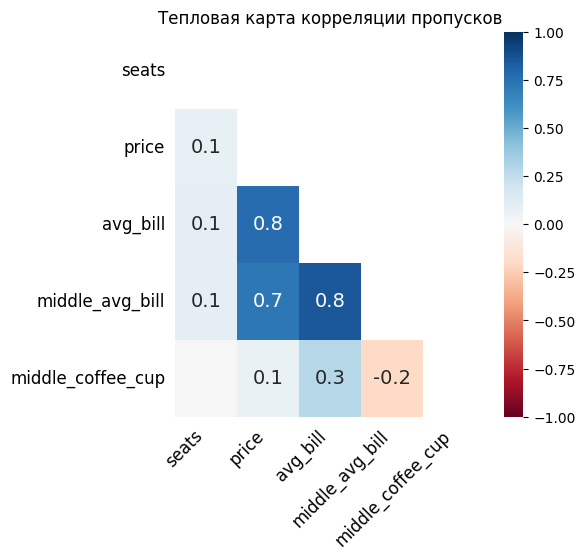

In [26]:
# Строим тепловую корреляцию пропусков
fig, ax = plt.subplots(figsize=(5, 5))
msno.heatmap(df, ax = ax)
plt.title('Тепловая карта корреляции пропусков', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()

Как показывает теловая карта, между столбцами `avg_bill` и `price` действительно наблюдается сильная положительная корреляция.

Для того чтобы понять за какие блюда обозначен средний чек в датафрейме проверим какие данные хранятся в столбце `avg_bill`

In [27]:
# Проверим за какие блюда есть средний чек

def ret_cat(avg_bill):
    return avg_bill.split(':')[0]
    
df_uniq_bill = df[df['avg_bill'].notna()]
df_uniq_bills = df_uniq_bill['avg_bill'].apply(ret_cat)
df_uniq_bills.unique()

array(['Средний счёт', 'Цена чашки капучино', 'Цена бокала пива'],
      dtype=object)

У нас есть три категории цены: средний счет в общем по заведению, средний счет для чашки капучино и средний счет для бокала пива.
Для первых двух у нас есть столбцы `middle_avg_bill` и `middle_coffee_cup`, но нет данных для пива. Создадим столбец `middle_beer`.
    

In [28]:
# Создадим функцию, которая выделит среднюю цену за бокал пива
def ret_price_beer(avg_bill):
    if pd.notna(avg_bill):
        if avg_bill.find('Цена бокала пива') > -1:
            res = avg_bill.split(":")[1].replace(' ₽', '')
            if res.find('–') > -1:
                return (int(res.split('–')[0]) + int(res.split('–')[1]))/2
            elif res.find('от') > -1 or res.find('до') > -1: 
                return int(res.split()[1])
            else:
                return int(res)
        else:
            return np.nan
    else:
        return np.nan
# Cоздадим столбец middle_beer
df['middle_beer'] = df['avg_bill'].apply(ret_price_beer)

In [29]:
# Приведем столбец moddle_beer к типу float64
df['middle_beer'] = df['middle_beer'].astype('float64')

Данные в столбце `price` могут варьироваться в зависимости от категории заведения и местоположения, поэтому оставим пропуски без изменений.

В столбцая `middle_avg_bill` и `middle_coffee_cup` пропуски составляют 62,54% и 93,6% соответственно. Проверим статистические даннные столбцов.

In [30]:
df[['middle_avg_bill','middle_coffee_cup']].describe()

,middle_avg_bill,middle_coffee_cup
count,3149.0,535.0
mean,958.053668,174.721495
std,1009.732845,88.951103
min,0.0,60.0
25%,375.0,124.5
50%,750.0,169.0
75%,1250.0,225.0
max,35000.0,1568.0


Столбец `middle_avg_bill` имеет аномальные значения. Минимальный ценник составляет 0, по сути это пропущенное значение. Максимальное значение тоже вызывает недоверие. Проверим  аномальные значения в столбце в датафрейме

In [31]:
df[(df['middle_avg_bill'] == 0) | (df['middle_avg_bill'] == 35000)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,middle_beer
3688,502d91289bc5470eabd77fd77cc79821,Кофемания,кофейня,"Москва, улица Новый Арбат, 19",Центральный административный округ,"ежедневно, круглосуточно",4.5,1,200,высокие,Средний счёт:от 0 ₽,0,<NA>,NaN
7177,07b4e95afe8b4d299f823dc4f9de6df5,Кафе,ресторан,"Москва, Каширское шоссе, 23, стр. 2",Южный административный округ,"ежедневно, круглосуточно",4.1,0,100,высокие,Средний счёт:20000–50000 ₽,35000,<NA>,NaN


Минимальное значение 0 в столбце `middle_avg_bill` можно расценивать как пропуск данных, поэтому заменим его на `Nan`.
Максимальное значение 35000 вероятнее всего является опечаткой. Заменим его на 3500.

In [32]:
# Заменим аномальные значения в столбце middle_avg_bill
df['middle_avg_bill'] = df['middle_avg_bill'].replace(0, np.nan)
df['middle_avg_bill'] = df['middle_avg_bill'].replace(35000, 3500)

В столбцах `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` и `middle_beer` так же большое количество пропуском, которые невозможно 
корректно заполнить, поэтому так же оставим их без изменений

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              8406 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   Int16  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3148 non-null   Int32  
 12  middle_coffee_cup  535 non-null    Int32  
 13  middle_beer        132 non-null    float64
dtypes: Int16(1), Int32(2), float64(2), int8(1), object(8)
memory usage: 771.8+ KB


Работа с пропусками закончена, можно переходить к поиску явных и неявных дубликатов

Но для начала посмотрим значения в столбцах `district`, `name` и `address` и по необходимости нормализуем их.

In [34]:
#Проверим все уникальные значения в столбце district
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

Здесь нет неявных дубликатов, далее найдем количество уникальных значений в столбце 'name'

In [35]:
# Посмотрим на количество уникальных значений в столбце name
df['name'].nunique()

5614

5614 уникальных наименований в столбце `name`. Выводить их на экран и изучать не имеет смысла. 
Сначала попробуем привести их к общему виду - нижний регист и уберем пробелы в начале и конце строки

In [36]:
# унифицируем названия заведений
df['name'] = df['name'].str.lower().str.strip()

In [37]:
# Заново проверяем количество уникальных значений в столбце name
df['name'].nunique()

5512

Количество уникальных значений уменьшилось, но изучить значения на предмет неявных дубликатов все равно сложно. 
Для поиска неявных дубликатов попробуем воспользоваться нечётким сопоставлением строк. Создадим два одинаковых списка с уникальными 
отсортированными значениями и сравним их при помощи библиотеки `fuzzywuzzy`

In [38]:
# Создаем два одинаковых списка
lst = list(df['name'].sort_values().unique())
lst1 = lst.copy()

In [39]:
# Создадим пустой датафрейм, для фиксации результатов
df_names = pd.DataFrame()
df_names = pd.DataFrame(columns=['name_1', 'name_2', 'fuzz'])

In [40]:
# Заполним пустой датафрейм циклом
for i in range(len(lst)):
    for j in range (i+1, len(lst1)):
        res = fuzz.ratio(lst[i], lst[j])
        # Запишем только те данные, в которых оценка схожести от 90 до 99
        if res >= 90 and res < 100:
            new_row = {'name_1': lst[i], 'name_2':lst[j], 'fuzz': res}
            new_df = pd.DataFrame([new_row])
            df_names = pd.concat([df_names, new_df], ignore_index = True)

In [41]:
# Проверим размер датафрейма
df_names.shape

(170, 3)

Получился датафрейм из 170 строк. С Этими данными уже можно работать.

In [42]:
df_names

,name_1,name_2,fuzz
0,9 bar coffe,9 bar coffee,96
1,a-cafe,ya-cafe,92
2,bufet,buffet,91
3,cafe 13,cafe13,92
4,caffeterria,caffetteria,91
...,...,...,...
165,шашлык,шашлыки,92
166,шашлычная,шашлычная77,90
167,шашлычный двор,шашлычный дворик,93
168,шашлычный двор № 1,шашлычный дворик № 1,95


Рассмотрим полученный датафрейм. Встречаются названия, которые отличаются количеством пробелов между словами (например `corner cafe & kitchen`
и `corner cafe&kitchen`),  разницей в одной букве (`9 bar coffee` и `9 bar coffe`) и отличия в названиях в знаках пунктуации (`яндекс лавка` и `яндекс.лавка`). Чтобы лучше разобраться в различиях выведем для примера пару значений.

In [43]:
df[(df['name'] == 'яндекс лавка') | (df['name'] == 'яндекс.лавка')].head(20)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,middle_beer
162,b6e3bd98def44c329ac6be289ab7d374,яндекс лавка,ресторан,"Москва, Дмитровское шоссе, 107с17",Северный административный округ,"ежедневно, 07:00–00:00",4.3,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
193,6d18ca8054414cdeb9e0e295a2168d2a,яндекс лавка,ресторан,"Москва, Алтуфьевское шоссе, 79А, стр. 25",Северо-Восточный административный округ,"ежедневно, 07:00–00:00",3.3,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
212,246d05777b044313ba89456fb59e8443,яндекс лавка,ресторан,"Москва, Алтуфьевское шоссе, 50",Северо-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,22,NaN,NaN,<NA>,<NA>,NaN
836,9a3459bb1d8a4f9aa903218e9b77eafa,яндекс лавка,ресторан,"Москва, Дубнинская улица, 12, корп. 2",Северный административный округ,Нет информации,4.0,1,124,NaN,NaN,<NA>,<NA>,NaN
1041,5967cdf7734a4b40bfc9fdcf3709af6e,яндекс лавка,ресторан,"Москва, улица Лётчика Бабушкина, 15",Северо-Восточный административный округ,"ежедневно, 07:00–00:00",4.2,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
1153,d698a153c5ad487f95f5786dfaa389ce,яндекс лавка,ресторан,"Москва, Будайский проезд, 1",Северо-Восточный административный округ,"ежедневно, 07:00–02:00",2.9,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
1206,6034f985488142999e911635cf99a939,яндекс.лавка,ресторан,"Москва, Таллинская улица, 14",Северо-Западный административный округ,"ежедневно, 07:00–00:00",4.1,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
1443,6d5779d7fd6b44599f2afdc532298423,яндекс лавка,ресторан,"Москва, Большой Волоколамский проезд, 12, корп...",Северо-Западный административный округ,"ежедневно, 07:00–00:00",4.0,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
1530,92d34773d27844fe8039223389584cc0,яндекс лавка,ресторан,"Москва, улица Викторенко, 16, стр. 5",Северный административный округ,"ежедневно, 07:00–00:00",4.2,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
1533,a8784e400ef143048350d6317d3f1e88,яндекс лавка,ресторан,"Москва, улица Космонавта Волкова, 6А",Северный административный округ,"ежедневно, 07:00–00:00",4.2,1,180,NaN,NaN,<NA>,<NA>,NaN


Яндекс Лавка представляет собой сеть заведений. Вероятность существования другого заведения с аналогичным названием крайне невысока, поскольку это может вызвать трудности с правами на товарный знак.
В дальнейшем мы будем следовать тому же принципу: различия в написании, касающиеся пробелов и знаков препинания, рассматриваются как опечатки в названии, если одно из названий относится к сетевому заведению.
Для удобства создадим еще один датафрейм, который по названию заведения объединит в себе адркса, категории и признак является ли заведение сетевым.

In [44]:
# Объединим датафрейм
temp_df= df_names.merge(df, left_on = 'name_1', right_on = 'name', how = 'left').merge(df, left_on = 'name_2', right_on = 'name', how = 'left', suffixes = ('_first','_sec'))

Проверим какие названия можно унифицировать

In [45]:
# Выведем спорные названия заведений и признаки являются ли они сетевыми
temp_df[['name_first', 'name_sec', 'chain_first', 'chain_sec']].head(10)

,name_first,name_sec,chain_first,chain_sec
0,9 bar coffe,9 bar coffee,0,1
1,9 bar coffe,9 bar coffee,0,1
2,9 bar coffe,9 bar coffee,0,1
3,9 bar coffe,9 bar coffee,0,1
4,9 bar coffe,9 bar coffee,0,1
5,9 bar coffe,9 bar coffee,0,1
6,9 bar coffe,9 bar coffee,0,1
7,a-cafe,ya-cafe,0,0
8,bufet,buffet,0,0
9,cafe 13,cafe13,0,0


Точно дубликатами будут являться те заведения, у которых при схожих названиях будут совпадать адреса, помотрим встречаются ли такие заведения.

In [46]:
df_con = temp_df[['name_first', 'name_sec', 'address_first', 'address_sec']]
df_con[df_con['address_first'] == df_con['address_sec']]

,name_first,name_sec,address_first,address_sec
9,cafe 13,cafe13,"Москва, Мясницкая улица, 13, стр. 11","Москва, Мясницкая улица, 13, стр. 11"
159,в парке вкуснее,в парке вкуснее!,"Москва, Северный административный округ, район...","Москва, Северный административный округ, район..."
379,миславнес,мисс лавнес,"Москва, Пролетарский проспект, 19, корп. 1","Москва, Пролетарский проспект, 19, корп. 1"
567,чайхана халал,чайхана халаль,"Москва, Смольная улица, 24Г, стр. 6","Москва, Смольная улица, 24Г, стр. 6"
617,чебуреки и манты,чебуреки манты,"Москва, Правобережная улица, 1Б","Москва, Правобережная улица, 1Б"


Создадим словарь, где ключом будет различные встречающиеся названия заведений, а значением - унифицированное название.

In [47]:
# Создаем словарь с унифицированными названиями
right_names = {'9 bar coffe' : '9 bar coffee',
      'cafe13' : 'cafe 13',
      'cofe fest' : 'cofefest',
      'corner cafe&kitchen' : 'corner cafe & kitchen',
      'drive cafe':'drive café',
      'festa&тесто':'festa & тесто', 
      'ho cho pho':'ho chu pho',
      "it's сот-кофейня" : "it's сот - кофейня",
      "jeffrey’s coffeeshop" : "jeffrey's coffeeshop",
      'phobo':'pho bo',
      'pizzamore':'pizza amore',
      'алло пицца':'алло! пицца', 
      'в парке вкуснее':'в парке вкуснее!',
      'да еда':'да, еда',
      "доминос пицца":"домино'с пицца",
      'есть хинкали & пить вино' : 'есть хинкали&пить вино',
      'кофепорт':'кофе-порт',
      'миславнес':'мисс лавнес',
      'перекресток':'перекрёсток',
      'ситипицца':'сити пицца',
      'стардог':'стардогс',
      'суши сет':'сушисет',
      'суши стор':'сушистор',
      'хинкали gали!':'хинкали - gали!', 
      'хинкали gали':'хинкали - gали!',
      'хинкали-gали!':'хинкали - gали!',
      'хинкали-gали':'хинкали - gали!',
      'чайхана халал':'чайхана халаль',
      'чебуреки и манты':'чебуреки манты',
      'яндекс.лавка':'яндекс лавка'}

In [48]:
# Меняем спорные названия на унифицированные при помощи словаря right_names
df['name'] = df['name'].replace(right_names)

In [49]:
# Проверим как изменилось количесвто уникальных значений в столбце name
df['name'].nunique()

5482

После всех преобразований получилось **5482** уникальных названий заведений в датафрейме. Далее перейдем к столбцу `address`. Проверим сколько уникальных адресов содержится в столбце

In [50]:
# Выведем количество уникальных значений в столбце address
df['address'].nunique()

5753

Довольно большое количество уникальных значений. Попробуем привести названия к единой стилистике

In [51]:
# Приведем данные в столбце address к нижнему регистру и удалим пробелы в начале и конце строки
df['address'] = df['address'].str.lower().str.strip()

In [52]:
# Посмотрим как изменилось количесвто уникальных значений в столбце address
df['address'].nunique()

5752

Число уникальных значений уменьшилось всего на 1 значение. Посмотрим уникальные значения, хранящиеся в столбце, чтобы понять как мы можем избавиться от неявных дубликатов

In [53]:
# Выводим уникальные значения столбца address для изучения
df['address'].sort_values().unique()

array(['москва, 1-й автозаводский проезд, 5',
       'москва, 1-й балтийский переулок, 3/25',
       'москва, 1-й варшавский проезд, 1ас9', ...,
       'москва, яузский бульвар, 11, стр. 1',
       'москва, яузский бульвар, 14/8', 'москва, № 7'],
      shape=(5752,), dtype=object)

После изучения уникальных значений адресов мы выявили различия, которые касаются различных форматов обозначений, таких как `ул.` или `улица`, `корп.` или `к.`, `стр.` или `с.`.
Проверим сколько в датафрейме вхождений с обозначением `ул`.

In [54]:
# Напишем функцию, которая возвращает адрес, в котором улица указана как ул.
def find_short_str(address):
    if address.find('ул.') > -1:
        return address
arr = []
arr.append(df['address'].apply(find_short_str))
arr[0].unique()

array([None, 'москва, ул. ярославская, 8, корп. 1',
       'москва, ул. профсоюзная, д.104'], dtype=object)

Мы нашли всего два значения с обозначением `ул.`. Заменим их на стандартное отображение, которое преобладает в датафрейме `[название] улица`.

In [55]:
#Заменим эти значения на унифицированные
df['address'] = df['address'].str.replace('ул. ярославская', 'ярославская улица')
df['address'] = df['address'].str.replace('ул. профсоюзная', 'профсоюзная улица')

Далее заменим значения в столбе `address`, в которых номер строения и корпуса записаны как `с` и `к` на `стр.` и `корп.` используя регулярные выражения

In [56]:
# Заменим обозначение строения с 'c' 'стр.'
df['address'] = df['address'].str.replace(r'с(\d+)', r', стр. \1', regex = True)

In [57]:
#  Заменим обозначение корпуса  с 'к' 'корп.'
df['address'] = df['address'].str.replace(r'к(\d+)', r', корп. \1', regex = True)

In [58]:
# После всех преобразований посмотрим как изменилось количество уникальных значений в столбце address
df['address'].nunique()

5597

Далее найдем дублирующие строки, хранящиеся в датафрейме

In [59]:
# Найдем количество явных дубликатов в датафрейме
df.duplicated().sum()

np.int64(0)

Явных дубликатов в данных нет, теперь проверим датафрейм на неявные дубликаты по столбцам `name` и `address`.

In [60]:
# Найдем количество неявных дубликатов
df.duplicated(subset = ['name', 'address']).sum()

np.int64(10)

In [61]:
# Проверим дубликаты для принятия решения, какую строку из дублируюших можно удалить
df[df.duplicated(subset = ['name', 'address'], keep = False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,middle_beer
20,1ab5691e4da844d3abadf085e0957852,чебуреки манты,кафе,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",4.3,1,148,NaN,NaN,<NA>,<NA>,NaN
55,504857294c514d08a9b5fd5d19a5f83e,чебуреки манты,кафе,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",4.3,0,148,NaN,NaN,<NA>,<NA>,NaN
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,<NA>,<NA>,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,<NA>,<NA>,NaN
416,9d656c7019664f58a16578d37ae8278a,чайхана халаль,ресторан,"москва, смольная улица, 24г, стр. 6",Северный административный округ,"ежедневно, круглосуточно",4.3,0,53,NaN,NaN,<NA>,<NA>,NaN
450,9d85da04badc4f44852bfc8048f1ffe0,чайхана халаль,ресторан,"москва, смольная улица, 24г, стр. 6",Северный административный округ,"ежедневно, круглосуточно",4.3,1,53,NaN,NaN,<NA>,<NA>,NaN
512,2367d669a8fd409dbf52c244ee17c88c,шоколадница,кафе,"москва, ленинградское шоссе, 16а, стр. 4",Северный административный округ,"ежедневно, 10:00–23:00",4.1,1,230,NaN,NaN,<NA>,<NA>,NaN
599,be007021c2a44e2f9488f7b3174d1a2b,в парке вкуснее!,кафе,"москва, северный административный округ, район...",Северный административный округ,"ежедневно, 10:00–21:00",2.2,0,<NA>,NaN,NaN,<NA>,<NA>,NaN
600,82ea6220bb4e4ffe83bfdf1dd7b4d556,в парке вкуснее!,кофейня,"москва, северный административный округ, район...",Северный административный округ,"ежедневно, 10:00–21:00",2.2,1,<NA>,NaN,NaN,<NA>,<NA>,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,<NA>,<NA>,NaN


У 10 заведений были обнаружены дублирующие строки. 

- `чебуреки манты` имеют 2 идентичные строки с различием в столбце `chain`. Оставим ту, которая имеет признак 1 в столбце `chain`.
- `кафе` находится в парке, поэтому вполне возможно, что это два разных заведения. так же отличается режим работы. С другой стороны у этих заведений одинаковый рейтинг, что странно, и строки не имеют каких-либо важных данных. Поэтому мы удалим любую из них.
- `чайхана халаль` полностью идентичные строки за исключением столбца `id`. Поэтому удалим любую из них.
- `в парке вкуснее!` незначительно отличаются в части категории заведения, оставим ту, которая имеет индификатор сетевого заведения.
-  `more poke` отличается графиком работы. Оставим строку с индификатором сетевого заведения = 1.
-  `раковарня клешни и хвосты` так же отличаются графиком работы, оставим строку со значением 1 в столбце `chain`.
-  `хлеб да выпечка` оставим ту строку, в которой есть данные по графику работы и индификатор сетевого заведения.
-  `cafe 13` оставим строку с большим индификатором.
-  `мисс лавнес` оставим стоку, у которой есть информация по среднему чеку.
-  `шоколадница` отличается категорией заведения, оставим ту стоку, в которой есть информация о количестве посадочных метс

In [62]:
# Создадим список со значениями индексов строк, которые необходимо удалить
del_string = [55, 215, 416, 599, 1430, 1509, 2211, 3109, 4613, 8402]
# Удаляем строки из датафрейма
df = df.drop(del_string)

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

Для создания столбца `is_24_7` найдем варианты режимов работы, которые подходят под категорию ежедневно и круглосуточно. Ранее мы уже бегло изучали эти данные. Для нас подходят варианты со словами `ежедневно` и  `круглосуточно`. Посмотрим какие строки содержат эти параметры


In [63]:
# Отберем уникальные значения в столбце hours где есть слова ежедневно или круглосуточно
df_24_7 = df[df['hours'].str.contains('ежедневно') | df['hours'].str.contains('круглосуточно')]
df_24_7['hours'].unique()

array(['ежедневно, 10:00–22:00', 'ежедневно, 09:00–22:00',
       'ежедневно, 10:00–23:00', 'ежедневно, 12:00–00:00',
       'ежедневно, круглосуточно', 'ежедневно, 10:00–21:00',
       'ежедневно, 08:00–22:00', 'ежедневно, 13:00–00:00',
       'ежедневно, 09:00–21:00', 'ежедневно, 10:00–19:00',
       'ежедневно, 08:00–21:00', 'ежедневно, 09:00–23:00',
       'ежедневно, 08:00–23:00', 'ежедневно, 11:00–00:00',
       'ежедневно, 09:00–02:00', 'ежедневно, 12:00–23:00',
       'ежедневно, 12:00–03:00', 'ежедневно, 16:00–06:00',
       'ежедневно, 09:00–01:00', 'ежедневно, 11:00–23:00',
       'ежедневно, 09:00–06:00', 'ежедневно, 10:00–21:30',
       'ежедневно, 08:00–00:00', 'ежедневно, 06:00–20:00',
       'ежедневно, 10:00–20:00', 'ежедневно, 11:00–22:00',
       'ежедневно, 10:30–23:00', 'ежедневно, 07:00–00:00',
       'ежедневно, 10:00–22:00, перерыв 16:00–16:20',
       'ежедневно, 13:00–04:00', 'ежедневно, 11:00–19:00',
       'ежедневно, 16:00–04:00', 'ежедневно, 09:00–00:00',


Подходит единственный график работы `ежедневно, круглосуточно`. Создадим столбец `is_24_7`, используя это значение в столбце `hours`. 

In [64]:
# Заполним столбец is_24_7
def fill_is_24_7(hours):
    if hours.find('ежедневно, круглосуточно') > -1:
        return True
    return False
    
df['is_24_7'] = df['hours'].apply(fill_is_24_7)

In [65]:
# Проверим как изменился датафрейм
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8396 entries, 0 to 8405
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8396 non-null   object 
 1   name               8396 non-null   object 
 2   category           8396 non-null   object 
 3   address            8396 non-null   object 
 4   district           8396 non-null   object 
 5   hours              8396 non-null   object 
 6   rating             8396 non-null   float64
 7   chain              8396 non-null   int8   
 8   seats              4788 non-null   Int16  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3148 non-null   Int32  
 12  middle_coffee_cup  535 non-null    Int32  
 13  middle_beer        132 non-null    float64
 14  is_24_7            8396 non-null   bool   
dtypes: Int16(1), Int32(2), bool(1), float64(2), int8(1), object(8)
memory usage: 

---

### Промежуточный вывод

В процессе предобработки данных были выполнены следующие действия:
- **Преобразование типов данных.**  Столбец `chain` был преобразован с понижением разрядности до `int8`, столбец `seats` был изменён на тип `Int16`, а столбцы `middle_avg_bill` и `middle_avg_bill` были преобразованы к типу `Int32`.
- **Работа с пропусками**.  В данных был выявлен значительный процент пропусков в столбцах `seats` -  42.96%, `price` - 60.56%, `avg_bill` - 54.6%,  `middle_avg_bill` - 62.54%, `middle_coffee_cup`-93,64%. Так же небольшое количество пропусков было обнаружено в столбце `hours` - 6.38%. Столбец `hours`  решено было заполнить пропуски значениями-индикаторами, а остальные столбцы были оставлены без изменений.

Также в столбце `avg_bill` были обнаружены данные о ценах за бокал пива и средние значения были вынесены в отдельный столбец `middle_beer`..

- **Поиск явных и неявных дубликатов**. Данные в столбце `name` были приведены к единой стилистике, и с помощью библиотеки `fuzzy wuzzy`  было выявлено 30 наименований заведений, являющихся неявными дубликатами. После обработки количество уникальных значений в столбце `name` сократилось на 132. Данные в столбце `address` были также приведены к единому стилю и значения были унифицированы значениями `улица` вместо `ул.`, `стр.` вместо `с.` и `корп.` вместо `к.`. Количество уникальных значений после преобразований уменьшилось на 156. Явных дубликатов не обнаружено, но было выявлено 10 неявных дубликатов по столбцам `name` и `address`, которые были удалены из датафрейма.
- **Создание столбца `is_24_7`**.  На основе значений о круглосуточной и ежедневной работе в столбце `hours` в датафрейм был добавлен столбец is_24_7, который содержит логические значениями `True` и `False`.
В результате всех преобразований был получен датафрейм, содержащий 8396 строк и 15 столбцов.


## <a id='eda'>4. Исследовательский анализ данных</a>
Проведем исследовательский анализ исходных данных.

В процессе анализа данных мы применим визуализации. Для каждого конкретного случая мы выберем наиболее подходящий тип визуализации с правильным оформлением. График будет включать заголовок, ясные подписи осей и, при необходимости, легенду, а его размер будет оптимальным для удобства изучения.

---

### <a id='count'>4.1 Количество объектов общественного питания по категориям.</a>

_Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией._

Для решения первой задачи узнаем абсолютное и относительное количество заведений общепита в разрезе каждой категории.

In [66]:
# Найдем общее количество заведений для каждой категории
df['category'].value_counts()

category
кафе               2372
ресторан           2040
кофейня            1412
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

In [67]:
# Найдем процентное отношение заведений для каждой категории
pd.DataFrame(round(df['category'].value_counts(normalize = True)*100,2)).style.background_gradient('coolwarm')

,proportion
category,
кафе,28.250000
ресторан,24.300000
кофейня,16.820000
"бар,паб",9.110000
пиццерия,7.540000
быстрое питание,7.180000
столовая,3.750000
булочная,3.050000


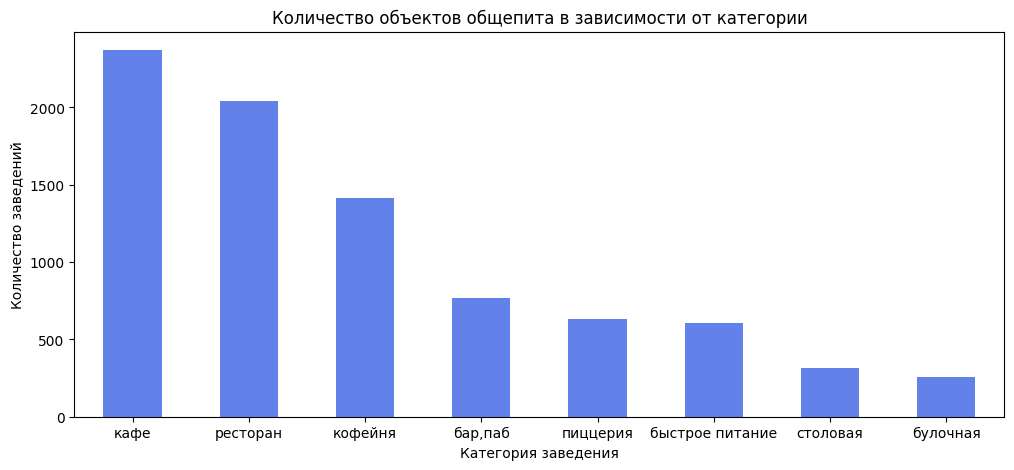

In [68]:
# Построим столбчатую диаграмму
plt.figure(figsize=(12, 5))

df['category'].value_counts().plot(
               kind='bar', 
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Количество объектов общепита в зависимости от категории',
               color = '#6282ea'
)
# Настраиваем оформление графика
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')


# Выводим график
plt.show()

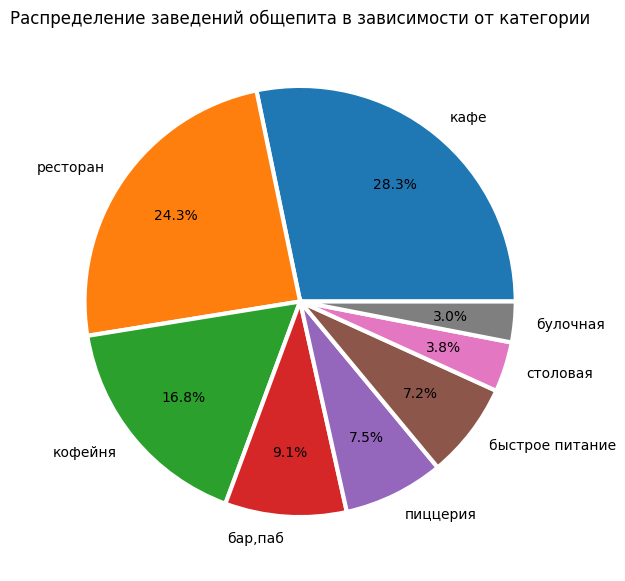

In [69]:
# Построим круговую диаграмму
plt.figure(figsize=(7, 7))

df['category'].value_counts().plot(
               kind='pie', 
               wedgeprops={'edgecolor': 'w', 'linewidth': 3},
               legend=False,
               title=f'Распределение заведений общепита в зависимости от категории',
               autopct='%1.1f%%',
               pctdistance=0.7
)
plt.ylabel('')
plt.xlabel('')
# Выводим график
plt.show()

В датафрейме представлены 8 категорий: кафе, ресторан, кофейня, бар-паб, пиццерия, быстрое питание, столовая и булочная.
В Москве наибольшее распространение имеют кафе, которые составляют 28,25% от общего числа заведений. Рестораны занимают вторую позицию с 24,29%, в то время как кофейни находятся на третьем месте, составляя 16,83%. Далее следуют бары и пабы с 9,11%, а пиццерии занимают 7,54%. Заведения быстрого питания составляют 7,18%, столовые — 3,75%, и завершают список булочные с 3,05%.

---

### <a id='count_district'>4.2. Распределение количества заведения по административным районам</a>

_Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями._

In [70]:
# Найдем общее количество заведений для каждого района
df['district'].value_counts()

district
Центральный административный округ         2241
Северный административный округ             894
Южный административный округ                891
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64

In [71]:
# Найдем процентное отношение заведений для каждого района
pd.DataFrame(round(df['district'].value_counts(normalize = True) * 100,2).sort_values(ascending = False)).style.background_gradient('coolwarm')

,proportion
district,
Центральный административный округ,26.690000
Северный административный округ,10.650000
Южный административный округ,10.610000
Северо-Восточный административный округ,10.600000
Западный административный округ,10.120000
Восточный административный округ,9.500000
Юго-Восточный административный округ,8.500000
Юго-Западный административный округ,8.440000
Северо-Западный административный округ,4.870000


In [72]:
# Создадим датафрейм, который будем использовать для создания диаграммы
df_dist = pd.DataFrame(df['district'].value_counts(), columns =  ['count'])
df_dist.reset_index(inplace = True)


In [73]:
# Создадим цветовую палитру для столбцатой диаграммы
color1 = ['#d55042']
color1.extend(['#5875e1'] * 8)

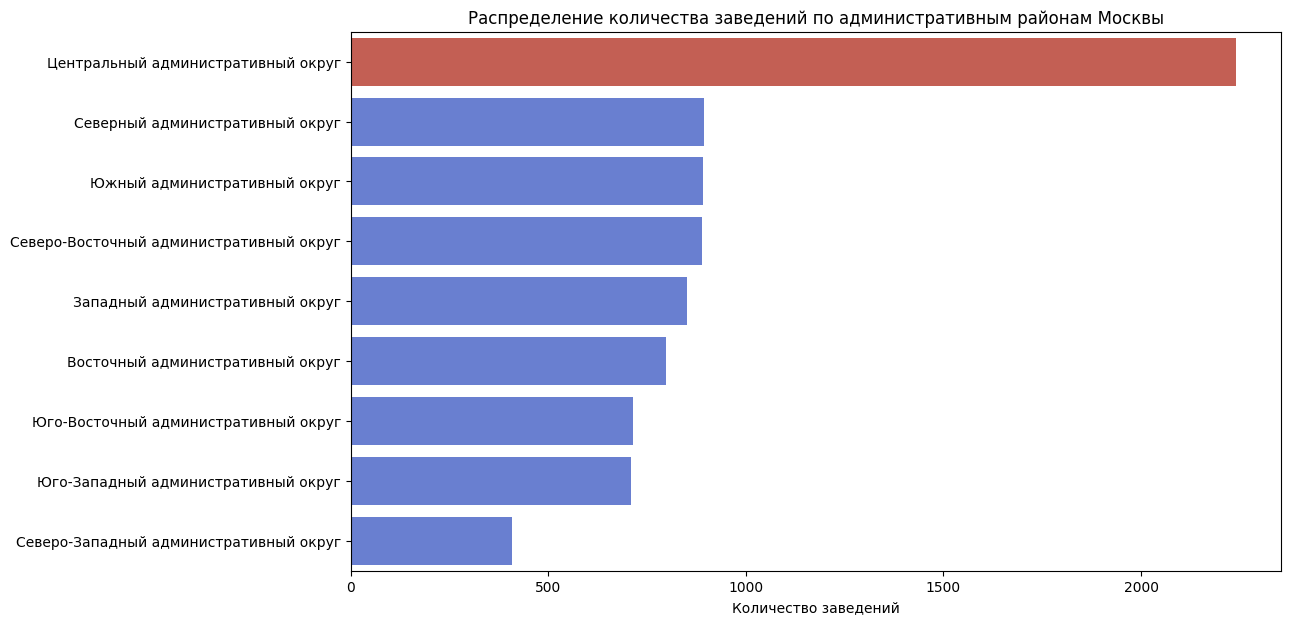

In [74]:
# Построим столбчатую диаграмму используя библиотеку seaborn
plt.figure(figsize=(12, 7))

sns.barplot(data = df_dist, 
            y = 'district', 
            x = 'count',
            hue = 'district',
            palette = color1
)
# Настраиваем оформление графика
plt.title('Распределение количества заведений по административным районам Москвы')
plt.ylabel('')
plt.xlabel('Количество заведений')


# Выводим график
plt.show()

In [75]:
# Создадим датафрейм, который хранит данные по ЦАО
df_centr_ao = df[df['district'] == 'Центральный административный округ']

In [76]:
# Исследуем количество категорий заведений в ЦАО
df_centr_ao['category'].value_counts()

category
ресторан           670
кафе               463
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: count, dtype: int64

In [77]:
pd.DataFrame(round(df_centr_ao['category'].value_counts(normalize=True)*100,2)).style.background_gradient('coolwarm')

,proportion
category,
ресторан,29.900000
кафе,20.660000
кофейня,19.100000
"бар,паб",16.240000
пиццерия,5.040000
быстрое питание,3.880000
столовая,2.950000
булочная,2.230000


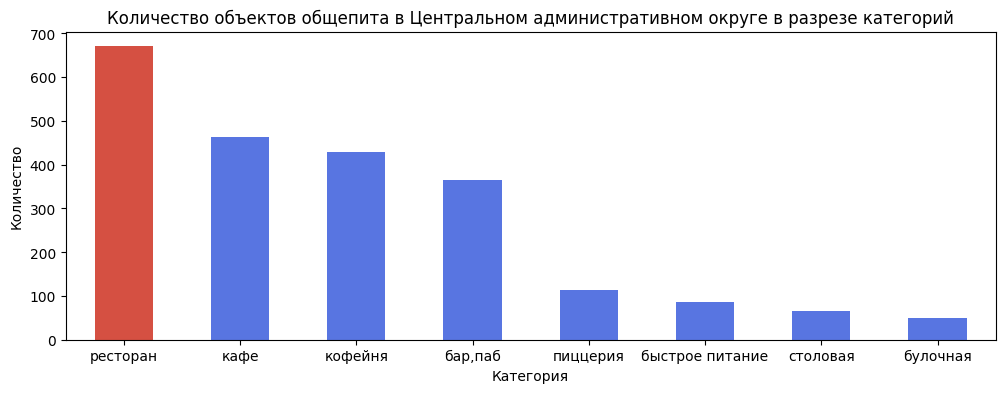

In [78]:
# Построим столбчатую диаграмму
plt.figure(figsize=(12, 4))

df_centr_ao['category'].value_counts().plot(
               kind='bar', 
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Количество объектов общепита в Центральном административном округе в разрезе категорий',
               color = color1
)
# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество')

# Выводим график
plt.show()

В датафрейме представлено 9 административных округов Москвы. Наибольшее количество заведений общественного питания сосредоточено в Центральном административном округе (26,7%). Наименьшее количество заведений наблюдается в Северо-Западном административном округе (4,87%). В других районах Москвы количество заведений примерно одинаковой и варьируется в пределах 8,44 - 10,66%.

В Центральном административном округе преобладают рестораны (29,9%). Далее идут кафе (20,66%), кофейни (19,1%) и бары (16,24%). Меньше всего в ЦАО
заведений быстрого питания (3,88%), столовых (2,95%) и булочных (2,23%). Доля пиццерий так же мала и составляет 5 %.

---

### <a id='chain'>4.3 Соотношение сетевых и несетевых заведений</a>

_Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации._

In [79]:
# Найдем количество сетевых и несетевых заведений 
df['chain'].value_counts()

chain
0    5192
1    3204
Name: count, dtype: int64

In [80]:
# Найдем количесвтао сетевых и несетевых заведений 
pd.DataFrame(round(df['chain'].value_counts(normalize = True)*100,2)).style.background_gradient('coolwarm')

,proportion
chain,
0,61.840000
1,38.160000


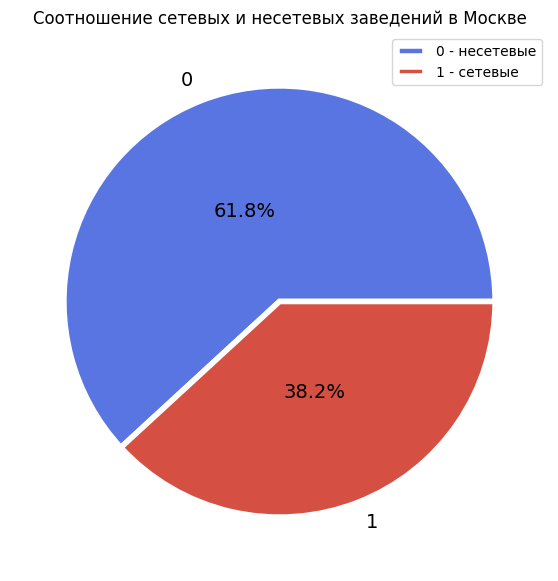

In [81]:
plt.figure(figsize=(7, 7))
df['chain'].value_counts().plot(kind = 'pie',
                                legend = True,
                                wedgeprops={'edgecolor': 'w', 'linewidth': 4},
                                autopct='%1.1f%%',
                                textprops={'fontsize': 14},
                                pctdistance=0.45,
                                colors = ['#5875e1', '#d55042']
                                
)
plt.title('Cоотношение сетевых и несетевых заведений в Москве')
plt.legend(['0 - несетевые','1 - сетевые'])
plt.ylabel('')
plt.show()

In [82]:
# Проверим какие категории преобладают для сетей, а какие для несетевых заведений
df_chain_category_percent = (round(df.groupby(['category', 'chain'])['id'].count()/df.groupby(['category'])['id'].count()*100,2)).unstack(fill_value = 0)
df_chain_category_percent

chain,0,1
category,,
"бар,паб",77.91,22.09
булочная,38.67,61.33
быстрое питание,61.53,38.47
кафе,67.16,32.84
кофейня,49.08,50.92
пиццерия,47.87,52.13
ресторан,64.22,35.78
столовая,72.06,27.94


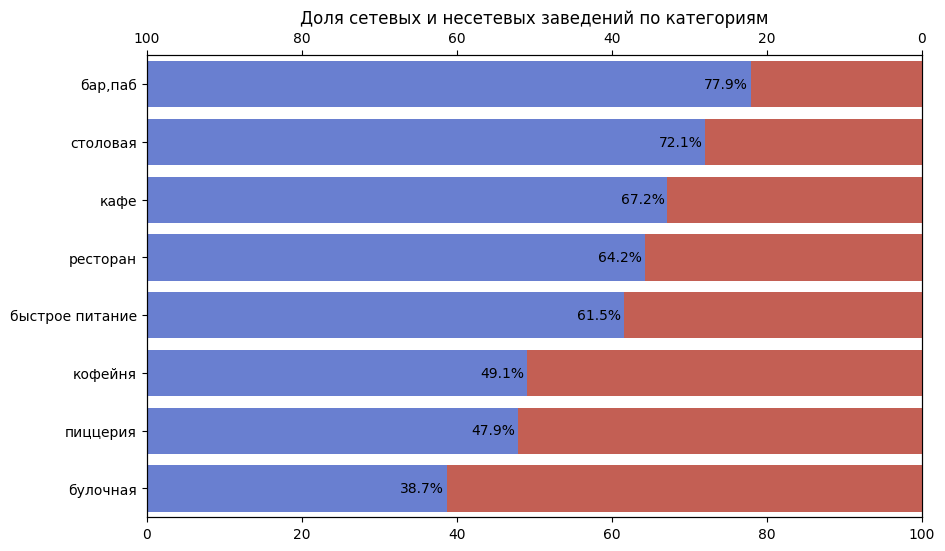

In [83]:
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=pd.DataFrame(df_chain_category_percent.iloc[:, 0].sort_values(ascending= False)), 
            x=0, 
            y='category',
            ax=ax1, 
            hue = 'category',
            palette = ['#5875e1']*8
           )
ax1.set_xlim(0, 100)
ax1.set_xlabel('')
ax1.set_ylabel('')
#ax1.set_xlabel('Значение 1 (слева направо)', color='tab:blue')
for p in ax1.patches:
    # Получаем ширину столбца (фактическое значение данных)
    width = p.get_width()
    # Получаем координаты Y центра столбца
    y_center = p.get_y() + p.get_height() / 2.0
    
    # Добавляем текст (метку данных) справа от столбца
    ax1.text(
        width - 6,                 # Координата X (справа от конца столбца + небольшой отступ)
        y_center,                    # Координата Y (по центру столбца)
        f'{width:.1f}%',             # Сам текст (форматируем как число с 1 знаком после запятой и знаком %)
        ha='left',                   # Выравнивание по горизонтали: слева от точки X
        va='center',                 # Выравнивание по вертикали: по центру точки Y
        color='black',               # Цвет текста
        fontsize=10                  # Размер шрифта
    )

ax2 = ax1.twiny()

sns.barplot(data= pd.DataFrame(df_chain_category_percent.iloc[:, 1].sort_values(ascending= True)),
            x=1, 
            y='category',
            ax=ax2, 
            hue = 'category',
            palette = ['#d55042']*8
            )
ax2.set_xlim(0, 100)
ax2.set_xlabel('')
ax2.invert_xaxis()

plt.title("Доля сетевых и несетевых заведений по категориям")
plt.show()

В Москве преобладают несетевые заведения общественного питания (61,8%). Сетевые заведения составляют 38,2%.

Среди сетевых заведений наиболее распространены булочные, пиццерии и кофейни. Среди несетевых бары, столовые кафе и рестораны (включая рестораны быстрого питания)

---

### <a id='seats'>4.4 Количество посадочных мест в заведениях</a>

_Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями._

Для ответа на вопросы 4 задачи изучим статистические показатели столбца `seats`.

In [84]:
# Изучаем статистические показатели столбца seats
df['seats'].describe()

count        4788.0
mean     108.336884
std      122.879888
min             0.0
25%            40.0
50%            75.0
75%           140.0
max          1288.0
Name: seats, dtype: Float64

Можно предположить, что данные распределены неравномерно и имеют выбросы. Об этом говорит большая разница между средним значением и медианой,
а так же большая разница между третьим квартилем и максимальным значением. Чтобы убедиться в этом построим гистограмму распределения значений и диаграмму размаха для столбца `seats`.

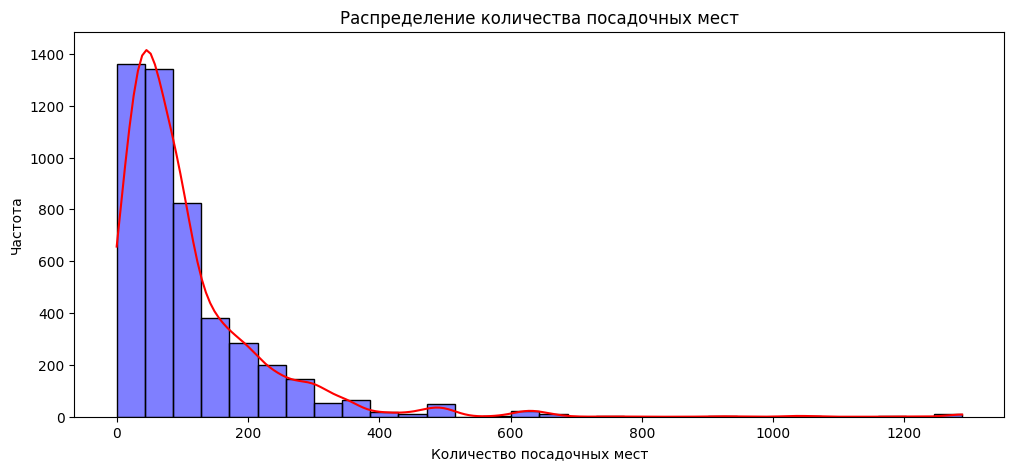

In [85]:
plt.figure(figsize=(12, 5))
ax = sns.histplot(data = df, 
                  x = 'seats',
                  bins = 30,
                  kde = True,
                  color = 'blue'
            )
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
ax.lines[0].set_color('red')
plt.show()

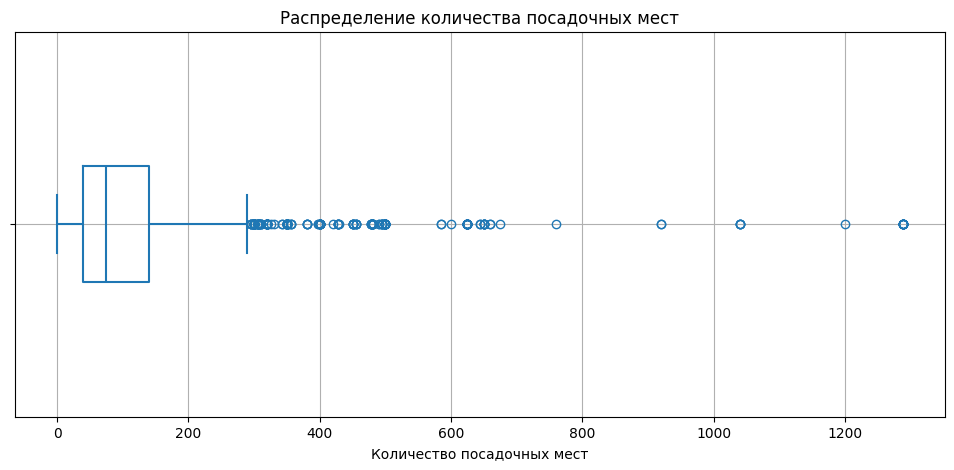

In [86]:
plt.figure(figsize=(12, 5))
sns.boxplot(data = df,
            x = 'seats',
            width = 0.3,
              fill = False
            )
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.grid()
plt.show()


Наличие значительных выбросов приводит к тому, что стандартное отклонение оказывается выше среднего и медианы, которые также имеют заметную разницу. 
Заведения, имеющие более 600 посадочных мест, вызывают сомнения, но не являются ошибкой в данных. Возможно, это заведения, которые специализируются на обслуживании мероприятий для большого числа людей. Кроме того, количество таких заведений не критично для общей картины, поэтому на основе этих данных можно построить графики для каждой категории заведений, ограничив визуализацию количеством посадочных мест до 600.

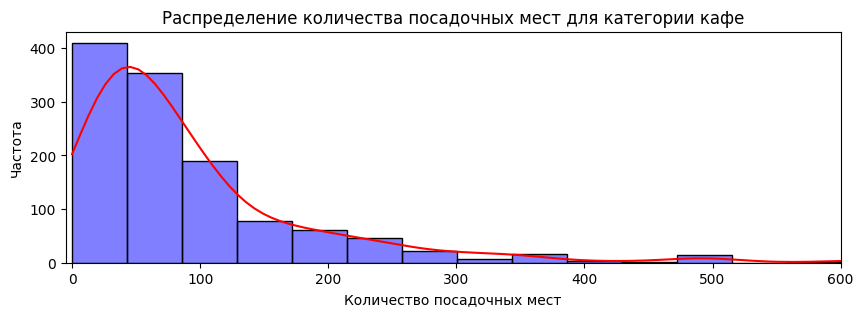

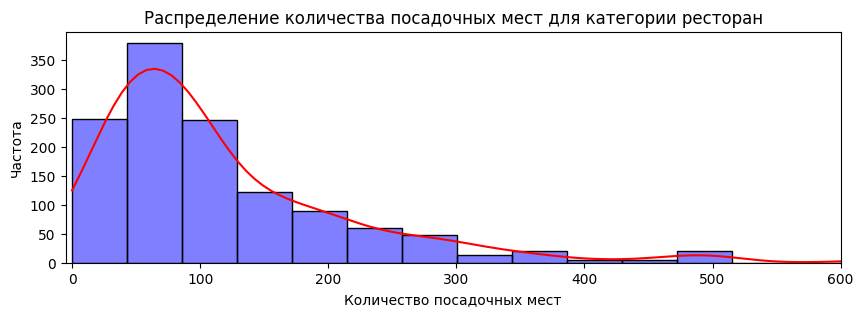

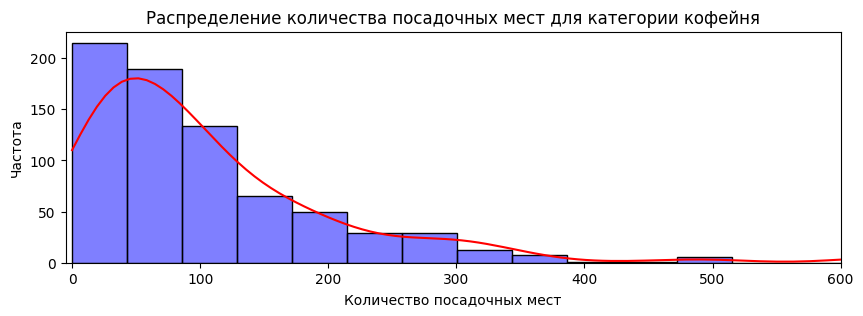

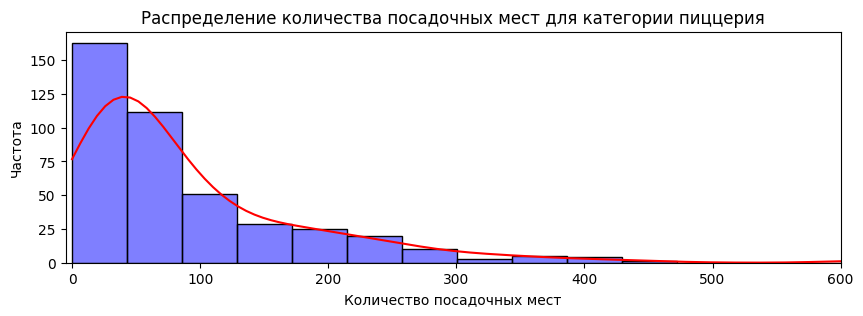

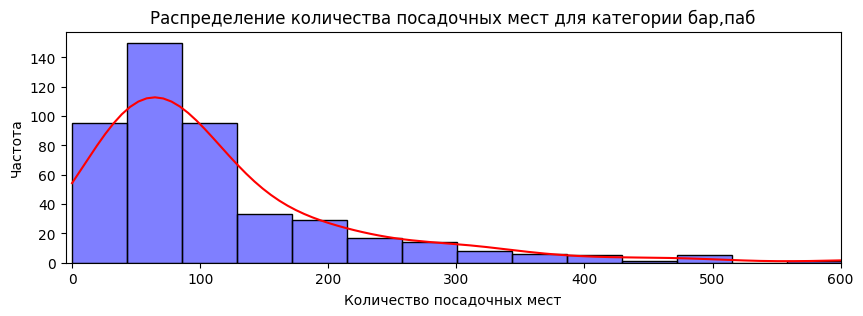

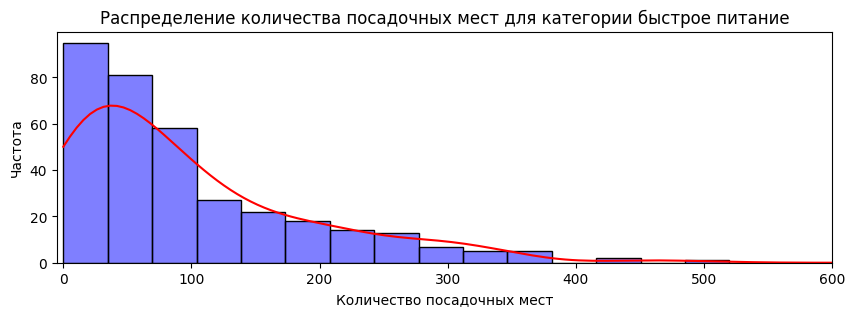

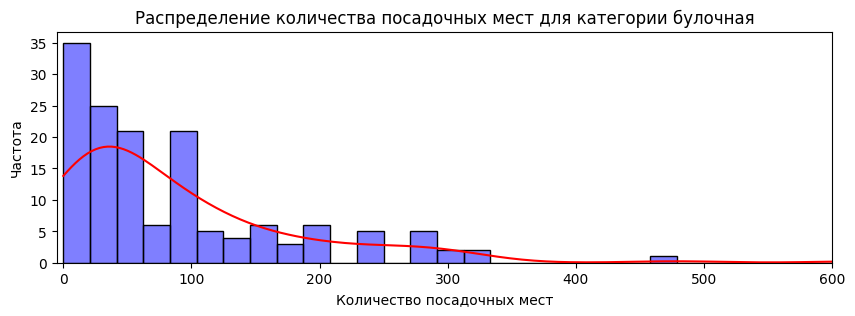

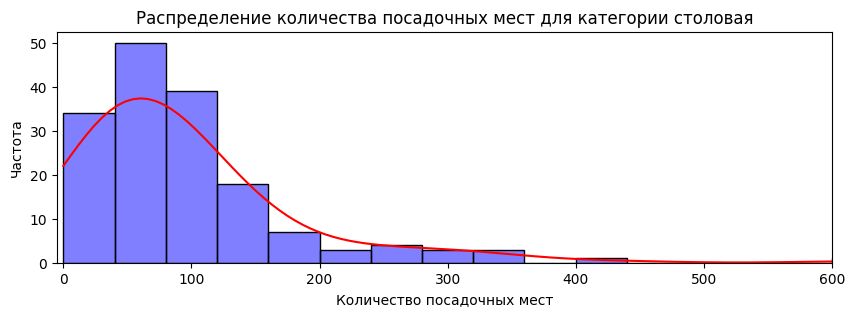

In [87]:
arr_category = list(df['category'].unique())

for category in arr_category:
    plt.figure(figsize=(10, 3))
    ax = sns.histplot(data = df[df['category'] == category], 
                      x = 'seats',
                      bins = 30,
                      kde = True,
                      color = 'blue'
                )
    plt.title(f'Распределение количества посадочных мест для категории {category}')
    plt.xlabel('Количество посадочных мест')
    plt.ylabel('Частота'),
    plt.xlim(-5, 600),
    ax.lines[0].set_color('red')
    plt.show()

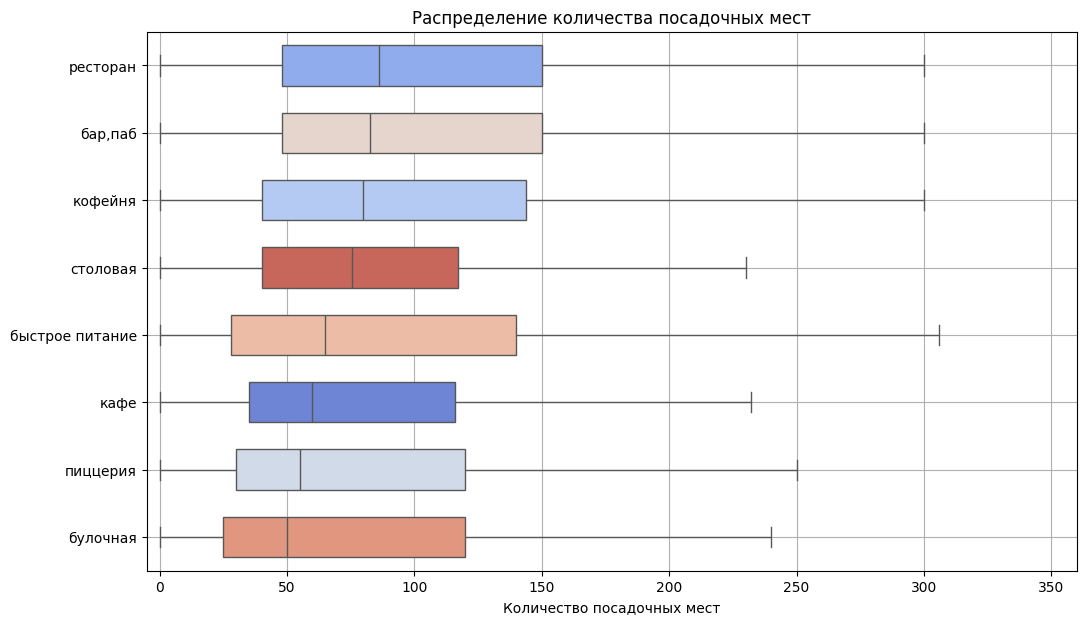

In [88]:
# Создадим лист с отсортированными категориями заведений по медиане количества посадочных мест
seat_median_sort = df.groupby('category')['seats'].median().sort_values(ascending = False)
arr_cat_seats = list(seat_median_sort.index)

# Строим график
plt.figure(figsize=(12, 7))
sns.boxplot(data = df,
            y = 'category',
            x = 'seats',
            hue = 'category',
            palette = 'coolwarm',
            fliersize = 0,
            width = 0.6,
            order = arr_cat_seats
            )
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('')
plt.xlim(-5, 360)
plt.grid()
plt.show()

Для определения наиболее типичных значений по каждой категории заведения выберем медианные значения.

In [89]:
df_seats_median = pd.DataFrame(round(df.groupby('category')['seats'].median()).sort_values(ascending = False))

df_seats_median = df_seats_median.reset_index()
df_seats_median

,category,seats
0,ресторан,86.0
1,"бар,паб",82.0
2,кофейня,80.0
3,столовая,76.0
4,быстрое питание,65.0
5,кафе,60.0
6,пиццерия,55.0
7,булочная,50.0


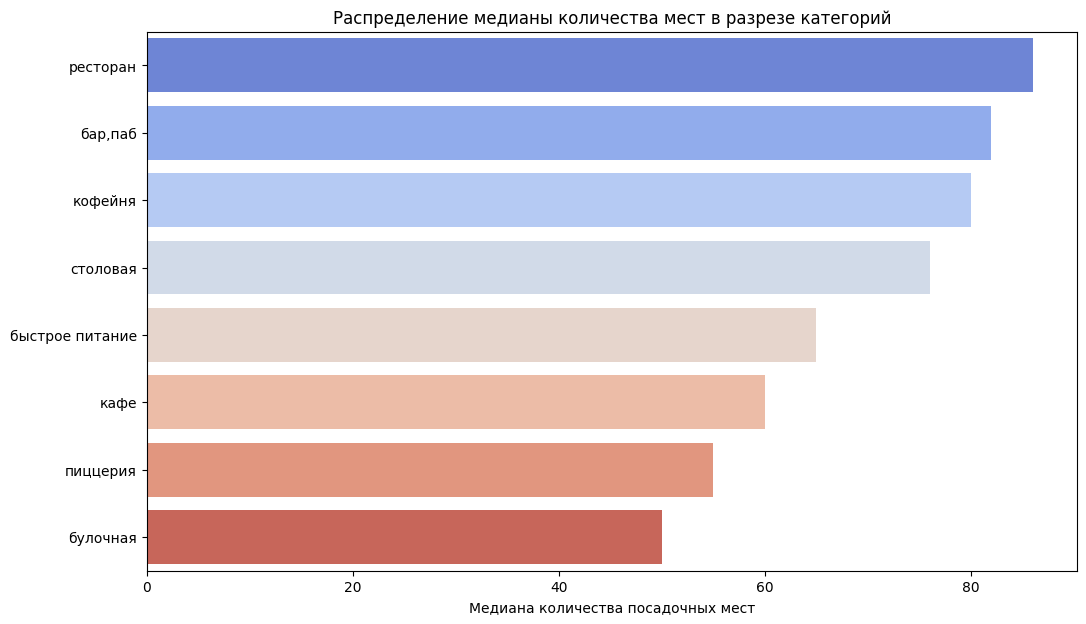

In [90]:
plt.figure(figsize=(12, 7))

sns.barplot(data = df_seats_median,
            y = 'category', 
            x = 'seats',
            hue = 'category',
            palette = 'coolwarm'
)
# Настраиваем оформление графика
plt.title('Распределение медианы количества мест в разрезе категорий')
plt.ylabel('')
plt.xlabel('Медиана количества посадочных мест')


# Выводим график
plt.show()

Медианные значения количества посадочных мест варьируются от 50 до 86 в зависимости от категории заведения. Самые большие медианные значения у ресторанов, баров и кофеен. Самое маленькое медианное значение у булочных.

---

### <a id='rating'>4.5 Рейтинг заведений</a>

_Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?_

In [91]:
# Создадим датафрейм для изучения среднего рейтинга по категориям
df_rating = pd.DataFrame(df.groupby('category')['rating'].mean().sort_values(ascending = False))
df_rating = df_rating.reset_index()
df_rating

,category,rating
0,"бар,паб",4.387712
1,пиццерия,4.301264
2,ресторан,4.290343
3,кофейня,4.277408
4,булочная,4.268359
5,столовая,4.211429
6,кафе,4.124663
7,быстрое питание,4.050249


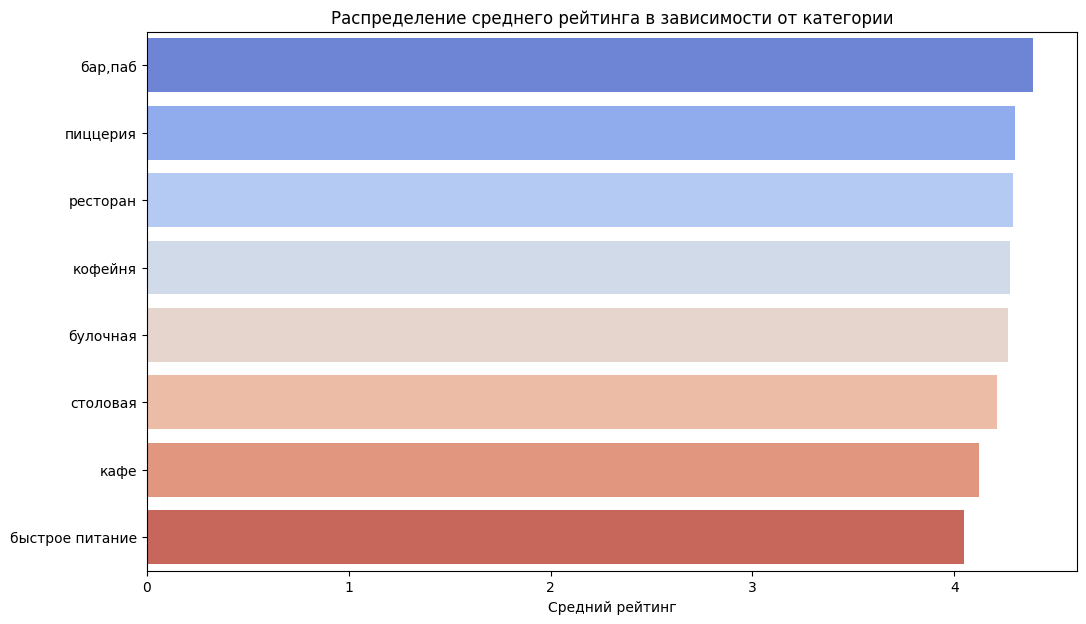

In [92]:
# Постороим столбцатую диаграмму
plt.figure(figsize=(12, 7))

sns.barplot(data = df_rating,
            y = 'category', 
            x = 'rating',
            hue = 'category',
            palette = 'coolwarm'
)
# Настраиваем оформление графика
plt.title('Распределение среднего рейтинга в зависимости от категории')
plt.ylabel('')
plt.xlabel('Средний рейтинг')


# Выводим график
plt.show()

Средние рейтинги заведений общепита рейтинги варьируются от 4,05 (рестораны быстрого питания)  до 4,38 (для баров и пабов). 

---

### <a id='corr'>4.6 Корреляция рейтинга заведений</a>

_Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её._

Чтобы понять, существует ли связь между данными построим матрицу корреляци столбца 'rating'. Для составления матрицы корреляции были отобраны данные, которые могут влиять на рейтинг заведения : категория, местоположение, статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведение круглосуточным. 

In [93]:
df_corr = df[['rating','category', 'district', 'chain', 'seats', 'price', 'is_24_7']]
df_corr = df_corr.dropna(subset = ['seats', 'price'])
correlation_matrix = df_corr.phik_matrix()
#correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by = 'rating', ascending = False)

interval columns not set, guessing: ['rating', 'chain', 'seats']


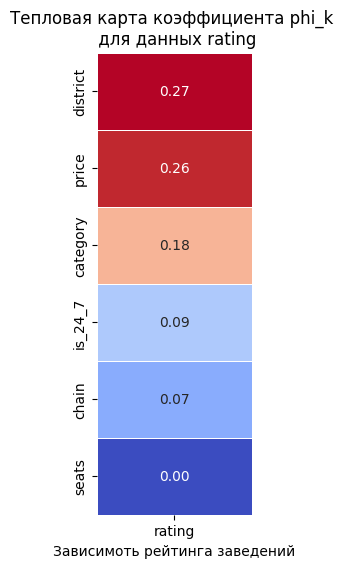

In [94]:
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by = 'rating', ascending = False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Зависимоть рейтинга заведений')

# Выводим график
plt.show()

Наибольшая корреляция рейтинга заведений наблюдается с районом местоположения заведения (0.27), ценовой категорией (0.26). Для остальных столбцов коэффициент корреляции снижается с 0.18 до 0.

Проверим самую сильную связь между рейтингом заведения и его местоположением. Предположим, что заведения, расположенные в более престижных или популярных районах, имеют тенденцию получать более высокие оценки от пользователей.

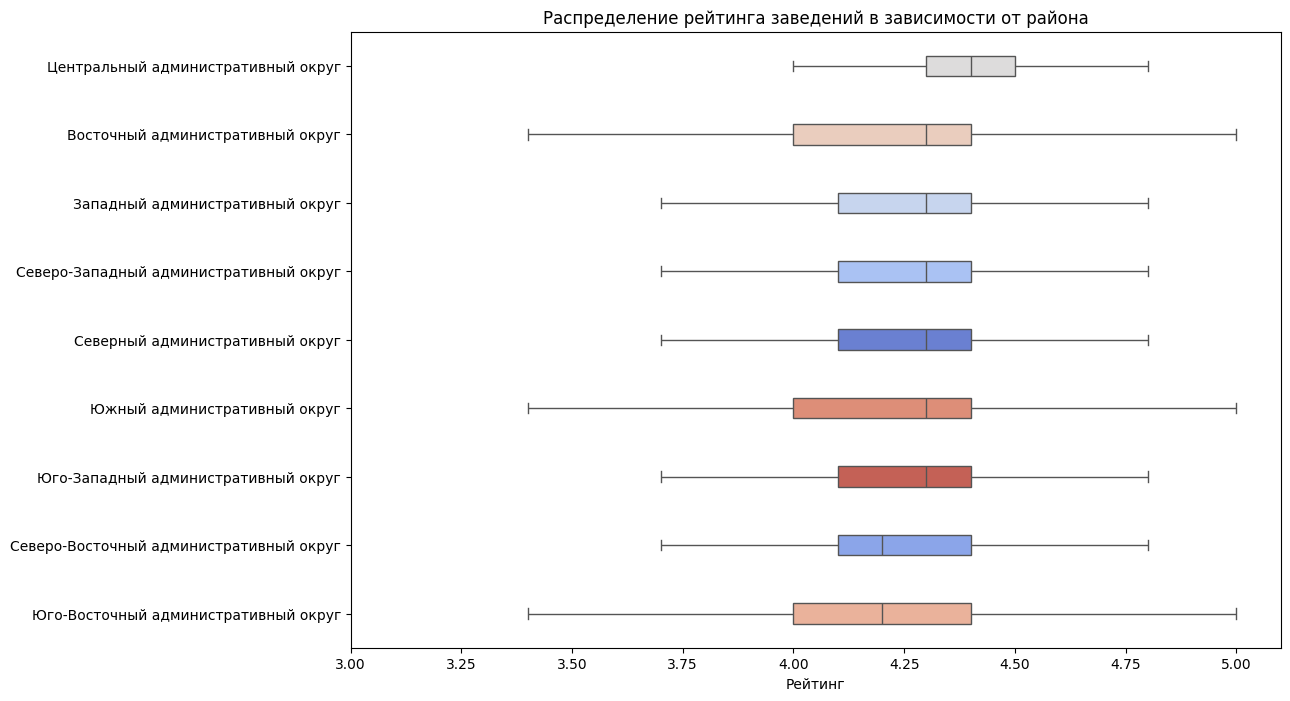

In [95]:
# Создадим лист с отсортированными районами заведений по медиане рейтинга
rat_median_sort = df.groupby('district')['rating'].median().sort_values(ascending = False)
arr_cat_rat = list(rat_median_sort.index)

# Cтроим график
plt.figure(figsize=(12, 8))
sns.boxplot(data = df,
            y = 'district',
            x = 'rating',
            width = 0.3,
            hue = 'district', 
            fliersize = 0,
            palette = 'coolwarm',
            order = arr_cat_rat 
            )
plt.xlim(3, 5.1)
plt.title('Распределение рейтинга заведений в зависимости от района')
plt.xlabel('Рейтинг')
plt.ylabel('')
plt.show()

Как видно из графика распределения медианное значение рейтинга действительно выше в Центральном административном округе. Самые низкие медианные значения в Северо-Восточном и Юго-Восточном АО. Это может быть связано с тем, что в ЦАО находятся более дорогие заведения, которые отличаются высоким уровнем сервиса, и рейтинг у которых выше.

Далее проверим связь между рейтингом заведения и его ценовой категорией. Положительная корреляция между рейтингом заведения и его ценовой категорией может указывать на то, что заведения с более высокой ценовой категорией получают более высокие оценки от клиентов. Это может быть связано с тем, что 
более дорогие заведения часто предлагают более высокое качество блюд и обслуживания, что может способствовать более высоким оценкам.

In [96]:
df.groupby('price')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
price,,,,,,,,
высокие,478.0,4.436611,0.314197,1.0,4.3,4.4,4.6,5.0
выше среднего,564.0,4.386348,0.223507,2.9,4.3,4.4,4.5,5.0
низкие,156.0,4.173077,0.372671,2.6,4.0,4.2,4.4,5.0
средние,2117.0,4.297874,0.295653,1.6,4.2,4.3,4.4,5.0


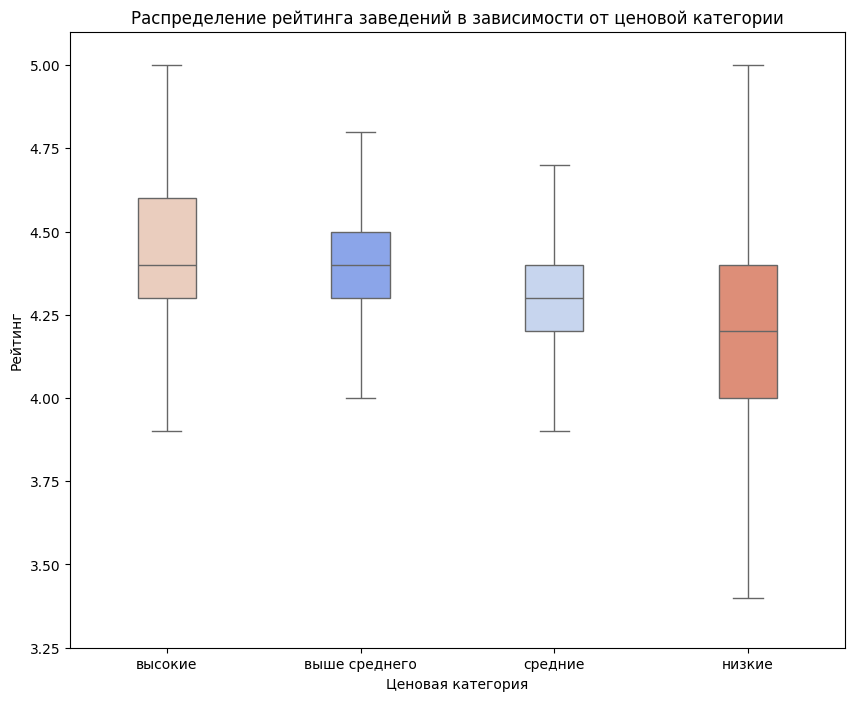

In [97]:
plt.figure(figsize=(10, 8))

sns.boxplot(data = df,
            x = 'price',
            y = 'rating',
            width = 0.3,
            hue = 'price', 
            fliersize = 0,
            palette = 'coolwarm',
            legend = False, 
            order = ['высокие','выше среднего', 'средние', 'низкие']
            )
plt.ylim(3.25,5.1)

plt.title('Распределение рейтинга заведений в зависимости от ценовой категории')
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')

plt.show()

В целом, график распределения подтверждает наличие положительной корреляции между ценовой категорией и рейтингом заведения. Более дорогие заведения, как правило, получают более высокие оценки, что может быть связано с качеством обслуживания, ожиданиями клиентов и общей атмосферой.

---

### <a id='top'>ТОП-15 сетевых заведений</a>

_Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями._

Чтобы ответить на вопросы 7 задачи, мы создадим датафрейм, сгруппированный по названиям сетевых заведений. В датафрейме мы определим количество заведений, вычислим среднее значение рейтинга и выявим наиболее распространённую категорию для этой сети.

In [98]:
df_top = df[df['chain'] == 1].groupby(['name']).agg({'id':'count', 
                                                     'rating': 'mean', 
                                                     'category': lambda x : x.mode()}).sort_values(by='id', ascending = False).head(15)
df_top

,id,rating,category
name,,,
шоколадница,119,4.178151,кофейня
домино'с пицца,76,4.169737,пиццерия
додо пицца,74,4.286486,пиццерия
яндекс лавка,72,3.855556,ресторан
one price coffee,71,4.064789,кофейня
cofix,65,4.075385,кофейня
prime,50,4.116000,ресторан
хинкальная,44,4.322727,кафе
кофе-порт,42,4.147619,кофейня


Построим ТОП-15 сетевых заведений Москвы

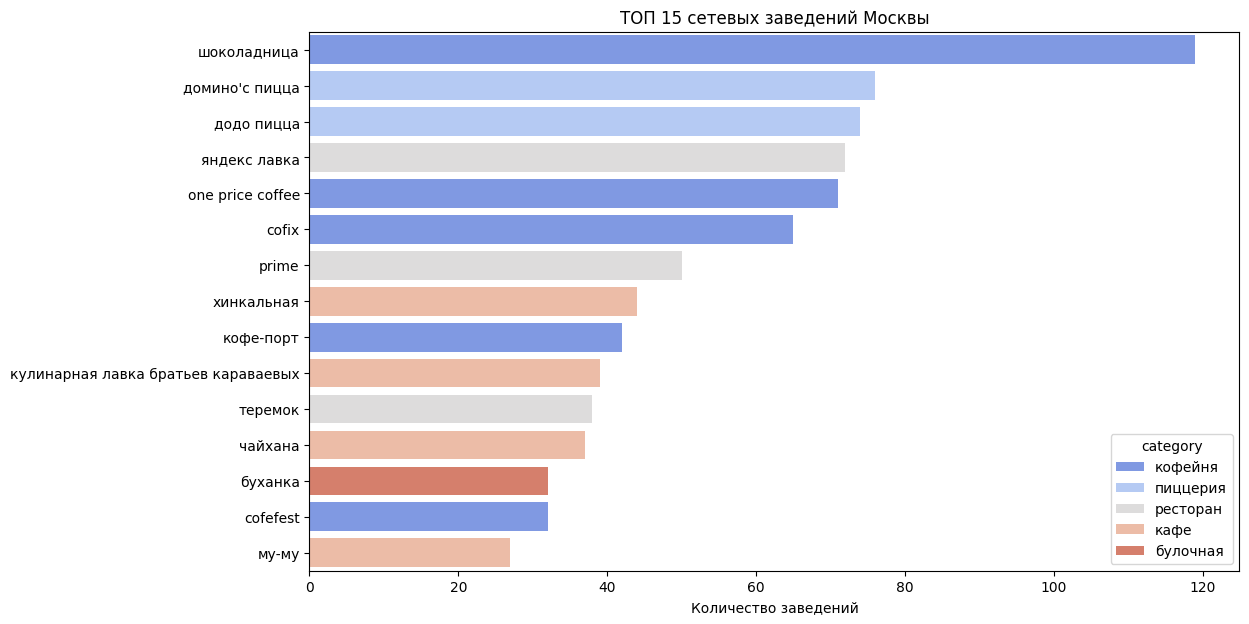

In [99]:
# Постороим столбцатую диаграмму
plt.figure(figsize=(12, 7))

sns.barplot(data = df_top,
            y = df_top.index, 
            x = 'id',
            hue = 'category',
            palette = 'coolwarm'
)
# Настраиваем оформление графика
plt.title('ТОП 15 сетевых заведений Москвы')
plt.ylabel('')
plt.xlabel('Количество заведений')


# Выводим график
plt.show()

На первом месте в ТОП-15 сетевых заведений Москвы занимает кофейня **Шоколадница** с рейтингом 4,17. На втором и третьем располагаются пиццерии **Домино'с пицца** с рейтингом 4,16 и **Додо пицца** с рейтингом 4,28.

---

### <a id='middle_bill'>4.8 Средний чек заведения в зависимости от района</a>

_Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями._


Для сравнения среднего чека заведения ЦАО с другими административными округами в датафрейме создадим колонку is_center, которая будет содержать булевые значения `True` в случае, если ресторан находится в ЦАО и `False`, если ресторан находится в другом районе.

In [100]:
def id_centr_district(district):
    if district == 'Центральный административный округ':
        return True
    return False
    
df['is_center'] = df['district'].apply(id_centr_district)

In [101]:
df.groupby('is_center')['middle_avg_bill'].describe()

,count,mean,std,min,25%,50%,75%,max
is_center,,,,,,,,
False,2089.0,824.743897,714.566693,30.0,350.0,600.0,1150.0,11000.0
True,1059.0,1192.182247,919.720051,67.0,500.0,1000.0,1500.0,7250.0


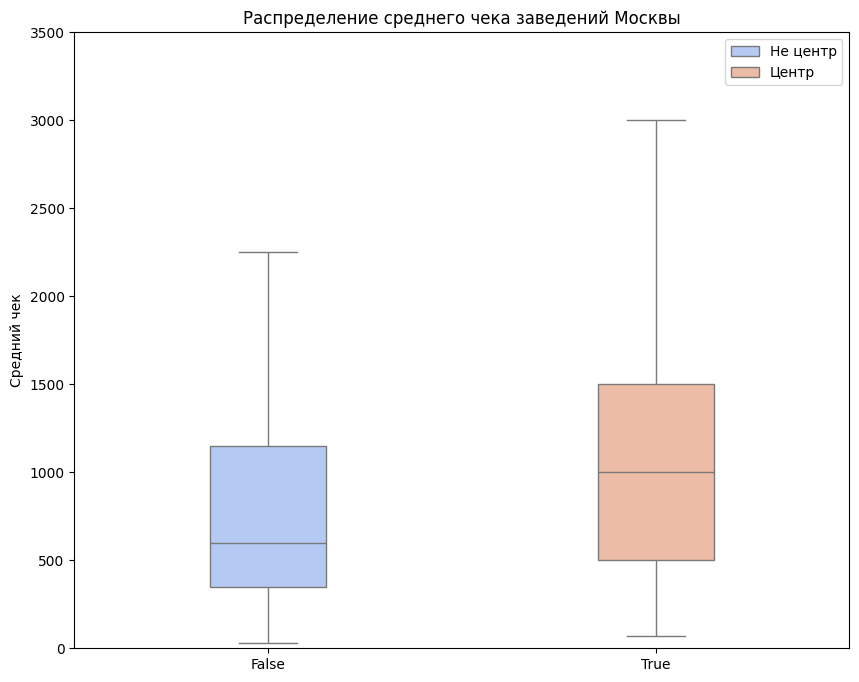

In [102]:
plt.figure(figsize=(10, 8))

sns.boxplot(data = df,
            x = 'is_center',
            y = 'middle_avg_bill',
            width = 0.3,
            hue = 'is_center', 
            fliersize = 0,
            palette = 'coolwarm'
            )
plt.ylim(0, 3500)
plt.title('Распределение среднего чека заведений Москвы')
plt.xlabel('')
plt.ylabel('Средний чек')
plt.legend(['Не центр','Центр'])

plt.show()

В целом, данные показывают, что удалённость от центра города существенно влияет на цены в заведениях общественного питания. Центральный административный округ предлагает более высокие цены, что может быть связано с различными факторами, включая аренду, спрос и уровень обслуживания.

In [103]:
# Создаем вспомогательный датафрейм
df_avg_bill = pd.DataFrame(df.groupby('district')['middle_avg_bill'].agg(['mean','median']).unstack(fill_value= True))
df_avg_bill.reset_index(inplace = True)
df_avg_bill.columns = ['kind','district','bill']

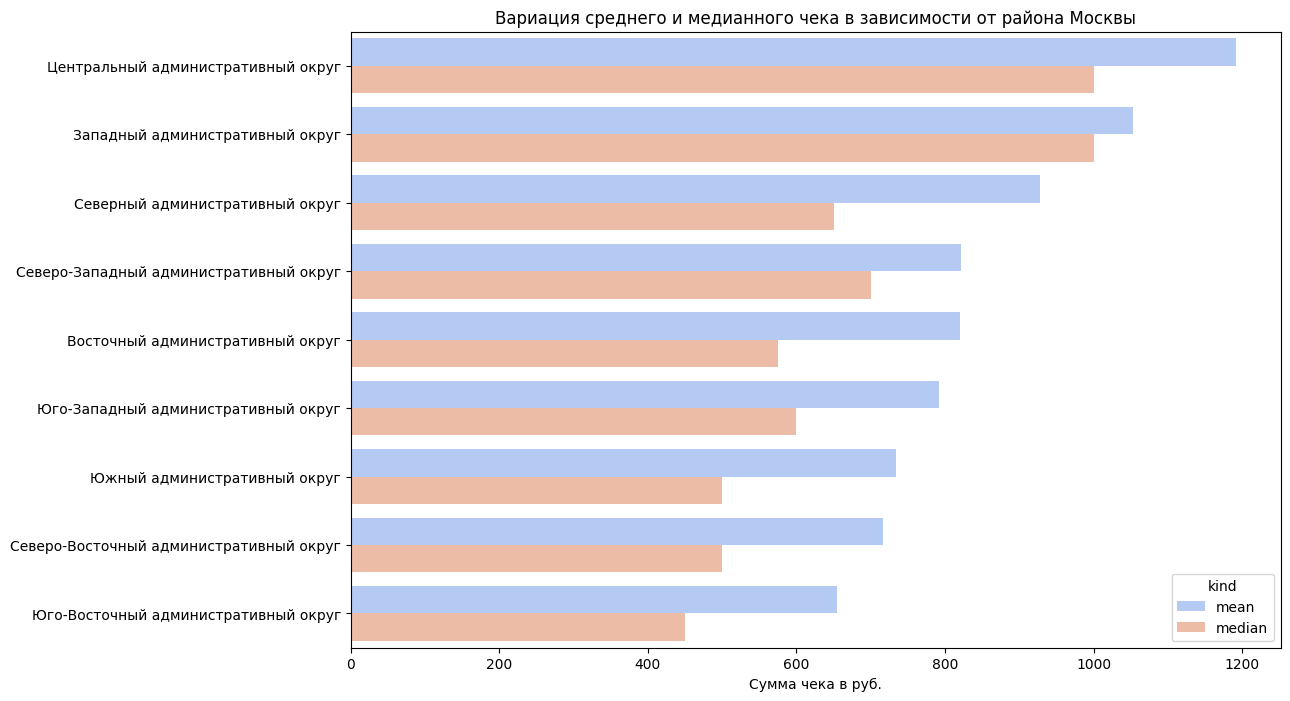

In [104]:
# Создаем список с отсортированными округами
arr_district = list(df_avg_bill[df_avg_bill['kind'] == 'mean'].sort_values(by = 'bill', ascending = False)['district'])

#Cтроим график
plt.figure(figsize=(12, 8))

sns.barplot(data = df_avg_bill,
               y = 'district',
                x = 'bill', 
                hue = 'kind',
                palette = 'coolwarm',
                order = arr_district
              )
plt.ylabel('')
plt.xlabel('Сумма чека в руб.')
plt.title('Вариация среднего и медианного чека в зависимости от района Москвы')
plt.show()

Центральный административный округ (ЦАО) занимает первое место по ценам. Здесь самые высокие средние (1192 руб.) и медианные (1000 руб.) чеки, что подтверждает важность центрального расположения для повышения цен в заведениях.
Наименьшие цены наблюдаются в Юго-Восточном административном округе (ЮВАО), где средний чек составляет всего 654 рубля, а медианный — 450 рублей. Эти показатели значительно ниже средних по городу.
В большинстве округов средний чек превышает медианный. Это указывает на то, что большинство заведений устанавливают цены на доступном уровне (около медианы), однако присутствие нескольких дорогих ресторанов "поднимает" средний показатель.
Западный административный округ занимает второе место по стоимости среди округов. В ЗАО цены более равномерно распределены по сравнению с другими округами (об этом говорит близкое расположение среднего (1053) и медианного чеков (1000). Здесь реже встречаются сильно завышенные ценовые "выбросы", и большинство заведений поддерживают стабильный высокий уровень цен.

---

### Промежуточный вывод

В Москве наибольшее количество заведений общественного питания составляют кафе, рестораны и кофейни, в то время как столовых и булочных значительно меньше. Основная масса этих заведений сосредоточена в Центральном административном округе, где рестораны занимают лидирующие позиции. В то же время, минимальное количество заведений наблюдается в Северо-Западном административном округе.

Среди заведений общепита в Москве преобладают независимые (несетевые) заведения, составляющие 61,84%. В числе сетевых заведений также доминируют кафе, рестораны и кофейни. 

Что касается посадочных мест, их среднее количество варьируется от 50 до 86. Наименьшее количество мест наблюдается в булочных, тогда как рестораны предлагают больше всего мест. В данных также зафиксированы заведения, не имеющие посадочных мест, а также те, где количество мест превышает 1000, что делает их подходящими для проведения крупных мероприятий, таких как свадьбы и корпоративы.

Медианные значения рейтингов заведений колеблются от 4,05 до 4,38. В то же время, в выборке имеются заведения с низкими рейтингами, например, 1.0, что может свидетельствовать о недовольстве клиентов, однако таких заведений крайне мало. Наивысший рейтинг отмечен у баров, тогда как рестораны быстрого питания имеют самые низкие оценки.

Анализ корреляции рейтингов с другими показателями показал положительную связь с районом расположения заведений и их ценовой категорией. Заведения, находящиеся в более престижных районах, как правило, имеют более высокие рейтинги. Кроме того, объекты общественного питания с высокими ценами чаще получают более высокие оценки по сравнению с заведениями среднего и низкого ценового сегмента.

В результате исследования был составлен список из 15 крупнейших сетевых заведений по количеству ресторанов в регионе. В тройку лидеров вошли: "Шоколадница" с 119 заведениями, "Доминос Пицца" с 76 ресторанами и "Додо Пицца" с 74 ресторанами.

Средний чек в заведениях Центрального административного округа на 40% выше, чем в других районах Москвы. Удаленность от центра Москвы существенно влияет на средний чек. В то же время, статус и покупательная способность жителей конкретного округа (как, например, в Западном административном округе) также имеют значительное значение в формировании цен.

## <a id='conclusion'>5. Итоговый вывод и рекомендации</a>

#### Общий обзор проделанной работы.
В рамках данного проекта был проведен исследовательский анализ рынка общественного питания в Москве. Исходные данные были представлены в виде двух отдельных датасетов, которые были проанализированы и объединены в один датафрейм. В процессе работы были выполнены операции по преобразованию данных, а также заполнению пропусков, что позволило улучшить качество анализа. В результате было выявлено и удалено 10 строк, представляющих собой дубликаты.

Далее был проведен анализ количества объектов общественного питания по различным категориям. Также было исследовано распределение заведений по административным районам Москвы, включая детальное рассмотрение распределения каждой категории в Центральном административном округе. Особое внимание было уделено соотношению сетевых и неявляющихся такими заведений в рамках различных категорий.

Кроме того, было проанализировано количество посадочных мест в заведениях, что позволило выявить наиболее распространенное количество мест для каждой категории. Рейтинги заведений также стали объектом исследования, где был выявлен положительный корреляционный эффект между рейтингом заведений и их расположением, а также ценовыми категориями.

В результате анализа был составлен список ТОП-15 сетевых заведений по количеству объектов в регионе. Также была изучена вариация среднего чека в зависимости от района Москвы, что дало возможность выявить тенденции ценового сегмента. Исследовательский процесс сопровождался визуализациями, что позволило наглядно представить полученные результаты и сделать выводы более понятными.

#### Главные выводы.
1.	**Структура рынка по категориям**:
•	кафе и оестораны формируют основу рынка, занимая совокупно более 50% от общего количества заведений.
•	Наименьшая представленность зафиксирована в категориях булочные" и столовые.
2.	**Географическое распределение (Административные районы)**:
•	Центральный административный округ (ЦАО) является ключевым хабом рынка общественного питания, концентрируя 26,7% всех заведений.
•	В структуре ЦАО преобладают рестораны и кофейни, что указывает как на высокий уровень конкуренции, так и на значительный спрос.
3.	**Сетевой vs Несетевой формат**:
•	На рынке Москвы доминируют несетевые заведения.
•	Среди сетевых форматов лидируют булочные, пиццерии" и кофейни.
4.	**Вместимость заведений (Посадочные места)**:
•	Средний диапазон посадочных мест составляет от 50 до 86.
•	Минимальная средняя вместимость характерна для булочных; максимальная — для ресторанов.
5.	**Рейтинги и факторы влияния**:
•	Средние пользовательские рейтинги находятся в диапазоне 4,05–4,3 балла.
•	Наивысший средний балл у баров, наименьший — у заведений быстрого питания.
•	Отмечена прямая зависимость между рейтингом заведения, его ценовой категорией и близостью к центру города.
6.	**Ценообразование**:
•	Наблюдается четкая тенденция увеличения среднего чека по мере приближения расположения заведения к центру Москвы.Так же был выявлены высокие средние чеки в Западном админимстративном округе.


#### Рекомендации.
1. **Инвестировать в премиум-сегмент в Центральном административном округе**:
   Высокий рейтинг и средний чек в ЦАО подтверждают наличие платежеспособного спроса и готовности клиентов платить за премиальный сервис и удобное расположение. Однако, для выхода на этот рынок необходимы значительные инвестиции и готовность к высокому уровню конкуренции.Так же можно рассмотреть Западный административный округ, у которого цены сопоставимы с ЦАО, а рейтинг ниже.

2. **Инвестирование в формат "Быстрого питания"** :
   У заведений быстрого питания самый низкий средний рейтинг, что может указывать на неудовлетворённый спрос или низкий стандарт качест. Низкий рейтинг сигнализирует о возможности для нового игрока с более высоким качеством занять свою нишу и привлечь клиентов.

3. **Инвестирование в заведения с низкой и средней вместимостью**: 
    Чтобы минимизировать риски и повысить рентабельность, стоит фокусироваться на небольших концепциях (например, кофейни, булочные), 
    Небольшие заведения требуют меньших начальных инвестиций и имеют более высокую гибкость в управлении.

4. **Инвестирование в нишевые сегменты**:
    Барная индустрия демонстрирует самый высокий средний рейтинг, который говорит о лояльности аудитории и хороших перспективах в этом сегменте.